In [ ]:
# %config InlineBackend.figure_format = 'svg'

In [1]:
import os

notebook_file_name = "nopos_random_init_extract_LN_statistics_on_a_sample_compared_to_mean_load_trained_w_LN"
image_dir = f"{notebook_file_name}_images"
os.makedirs(image_dir, exist_ok=True)

In [2]:
import pytorch_lightning as pl
from pytorch_lightning import Trainer, loggers
from pytorch_lightning.callbacks import ModelCheckpoint, LearningRateMonitor
from torch.utils.data import DataLoader, TensorDataset
import torch
import torch.nn.functional as F
from torch.optim.lr_scheduler import StepLR

from transformer_lens import HookedTransformer, HookedTransformerConfig, utils
from pathlib import Path
from pytorch_lightning.loggers import TensorBoardLogger
import os

from scipy.linalg import norm
from transformer_lens import HookedTransformer, HookedTransformerConfig, utils
import torch
import numpy as np
import plotly.express as px
import plotly.io as pio
from jaxtyping import Float, Int # Read about this library
import tqdm.auto as tqdm
import einops
from transformer_lens.utils import to_numpy
from pathlib import Path
from torch.utils.data import TensorDataset, DataLoader
from datetime import datetime
# import pytorch_lightning as pl
from functools import partial
import pandas as pd

from transformer_lens.hook_points import (
    HookedRootModule,
    HookPoint,
)  # Hooking utilities

# Utils
def line(tensor, line_labels=None, yaxis="", xaxis="", title="", legend_title="", **kwargs):
    tensor = to_numpy(tensor)
    fig = px.line(tensor, **kwargs)

    showlegend=True if legend_title != "" else False

    # Update labels explicitly for x-axis and y-axis
    fig.update_layout(
        title=title,
        xaxis_title=xaxis,  # Set x-axis label
        yaxis_title=yaxis,  # Set y-axis label
        height=400,  # Optional: maintain height for consistency
        showlegend=showlegend,
        legend_title=legend_title  # Set legend title
    )
    
    # Apply line labels if provided
    if line_labels:
        for c, label in enumerate(line_labels):
            fig.data[c].name = label
    
    fig.show()

    

def imshow(tensor, yaxis="", xaxis="", **kwargs):
    tensor = to_numpy(tensor)
    plot_kwargs = {
        "color_continuous_scale": "RdBu",
        "color_continuous_midpoint": 0.0,
        "labels": {"x": xaxis, "y": yaxis},
    }
    plot_kwargs.update(kwargs)
    px.imshow(tensor, **plot_kwargs).show()

import plotly.io as pio

# pio.renderers.default = 'png'


# # Set default template to 'plotly_white' for a clean academic style
# pio.templates.default = "plotly_white"

# # Customize the global layout for academic style
# pio.templates["plotly_white"]['layout'].update({
#     'font': {
#         'family': 'Times New Roman',  # Common academic font
#         'size': 18                    # Larger font for readability in papers
#     },
#     'margin': dict(l=50, r=50, t=50, b=50),  # Adjust margins for clearer plots
#     'height': 400,  # Adjust plot size
#     'width': 800    # Adjust plot size
# });

# Load trained model

In [3]:
device='cpu'
def deactivate_position(model):
    model.pos_embed.W_pos.data[:] = 0.0
    model.pos_embed.W_pos.requires_grad = False

def freeze_embeddings(model):
    model.embed.W_E.requires_grad = False

def freeze_attention(model, l=0):
    model.blocks[l].attn.W_Q.requires_grad = False
    model.blocks[l].attn.W_K.requires_grad = False
    model.blocks[l].attn.W_V.requires_grad = False
    model.blocks[l].attn.W_O.requires_grad = False

    model.blocks[l].attn.b_Q.requires_grad = False
    model.blocks[l].attn.b_K.requires_grad = False
    model.blocks[l].attn.b_V.requires_grad = False
    model.blocks[l].attn.b_O.requires_grad = False


class LitTransformer(pl.LightningModule):
    def __init__(self, config, train_dataloader, val_dataloader):
        super().__init__()
        self.model = HookedTransformer(config)
        self.model.to(device)
        deactivate_position(self.model)
        freeze_embeddings(self.model)
        freeze_attention(self.model, l=0)
        # print(self.model.pos_embed.W_pos.data)
        # print(self.model.blocks[0].attn.W_Q.data)
        # print(self.model.W_E.device)
        self._train_dataloader = train_dataloader
        self._val_dataloader = val_dataloader

    def forward(self, tokens):
        return self.model(tokens.to(device))

    def training_step(self, batch, batch_idx):
        tokens, targets = batch
        tokens = tokens.to(device)
        targets = targets .to(device)
        logits = self(tokens)
        loss = self.loss_fn(logits, targets)
        self.log('train_loss', loss)
        return loss

    def validation_step(self, batch, batch_idx):
        tokens, targets = batch
        logits = self(tokens)
        loss = self.loss_fn(logits, targets)
        self.log('val_loss', loss)

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.parameters(), lr=5e-5, betas=(0.9, 0.95), weight_decay=0.1)
        scheduler = StepLR(optimizer, step_size=100, gamma=0.1)
        return [optimizer], [scheduler]

    def train_dataloader(self):
        return self._train_dataloader

    def val_dataloader(self):
        return self._val_dataloader

    def loss_fn(self, logits, labels, per_token=False):
        log_probs = logits.log_softmax(-1)
        correct_log_probs = log_probs.gather(-1, labels[..., None])[..., 0]
        if per_token:
            return -correct_log_probs
        else:
            return -correct_log_probs.mean()
################ Data
class CustomDataset(TensorDataset):
    def __init__(self, tokens, targets):
        super().__init__(tokens, targets)
BASE = Path('.').resolve() 
N_CTX = 64
TRAIN_RATIO = 0.8
TBLOGSDIR = f'tblogs'
D_VOCAB = 1_024
D_MODEL = 1_024
N_SAMPLES = D_VOCAB*10
BATCH_SIZE = N_SAMPLES 
EMB_STD = 0.025

train_dataset = torch.randint(low=0, high=D_VOCAB, size=(N_SAMPLES, N_CTX), device=device)
test_dataset = torch.randint(low=0, high=D_VOCAB, size=(N_SAMPLES, N_CTX), device=device)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

################ Data
cfg = HookedTransformerConfig(
    n_layers=1,
    d_model=D_MODEL,
    d_head=D_MODEL,
    n_heads=1,
    d_mlp=D_MODEL*4,
    d_vocab=D_VOCAB,
    n_ctx=N_CTX,
    act_fn='relu',
    normalization_type='LNPre',
    device=device,
    use_hook_mlp_in=True
)
def update_embedding(x):
    import torch.nn as nn
    std = np.sqrt(1.0 / (x.shape[1]))
    return nn.init.normal_(x, mean=0.0, std=std)

lit_model = LitTransformer(cfg, train_loader, test_loader)
lit_model.to(device)
model = lit_model.model

Moving model to device:  cpu


In [4]:
model.embed.W_E.data.std()

tensor(0.0250)

In [5]:
model.blocks[0].attn.W_Q.data.std()

tensor(0.0250)

In [6]:
update_embedding(model.embed.W_E)

Parameter containing:
tensor([[ 0.0028, -0.0205, -0.0119,  ..., -0.0328,  0.0031,  0.0184],
        [ 0.0251,  0.0112, -0.0255,  ...,  0.0240,  0.0096,  0.0328],
        [-0.0248, -0.0065, -0.0405,  ...,  0.0295,  0.0062, -0.0469],
        ...,
        [ 0.0028, -0.0324,  0.0399,  ..., -0.0019, -0.0266, -0.0110],
        [-0.0238,  0.0202,  0.0116,  ..., -0.0086, -0.0296, -0.0993],
        [ 0.0143,  0.0336,  0.0129,  ...,  0.0219,  0.0170,  0.0770]])

In [7]:
model.embed.W_E.data.std()

tensor(0.0312)

In [8]:
model.blocks[0].attn.W_Q.data.std()

tensor(0.0250)

In [9]:
logits, cache = model.run_with_cache(test_loader.dataset)
logits.shape

torch.Size([10240, 64, 1024])

In [13]:
# L0
n_layers = 1
for layer_id in range(n_layers):
    # Heads
    for i in range(cfg.n_heads):
        imshow(
            (np.exp(cache[f"blocks.{layer_id}.attn.hook_attn_scores"][:, i, :, :].mean([0]).cpu().numpy())),
            title=f"Layer {layer_id} Attention Pattern {i}",
            height=500,
            width=500,
        )

In [14]:
# L0
n_layers = 1
for layer_id in range(n_layers):
    # Heads
    for i in range(cfg.n_heads):
        imshow(
            to_numpy(cache["attn", layer_id][:, [i], :, :].mean([0, 1])),
            # title=f"Layer {layer_id} Attention Pattern {i}",
            height=500,
            width=500,
        )

In [15]:
line(cache['blocks.0.attn.hook_pattern'].mean(0).squeeze(0).var(-1), xaxis='Position', yaxis='Variance')

In [16]:
line(cache['blocks.0.attn.hook_pattern'][0].squeeze(0).var(-1), xaxis='Position', yaxis='Variance')

# Working cell

In [13]:
top_10_percent

NameError: name 'top_10_percent' is not defined

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------- Improved Activation Statistics Plotting ----------------
def plot_activation_statistics_improved(act='blocks.0.ln2.hook_normalized', q=0.1):
    # Get activations with shape: (batch, ctx, neurons)
    activations = cache[act]
    activations = activations.cpu().numpy()

    num_samples, n_positions, n_neurons = activations.shape
    print("Activations shape:", activations.shape)
    
    # Flatten (batch, ctx) to get X, and compute thresholds using the given quantiles.
    X = activations.reshape(-1, n_neurons)
    neurons_mean_val = X.mean(axis=0) 
    positive_neurons =  neurons_mean_val[neurons_mean_val>0]
    negative_neurons =  neurons_mean_val[neurons_mean_val<0]
    top_10_percent = np.quantile(positive_neurons, 1-q) # Returns a scalar
    bottom_10_percent = np.quantile(negative_neurons, q)
    print(top_10_percent, bottom_10_percent)
    avg_top10_neurons_mask = neurons_mean_val>top_10_percent
    avg_bottom10_neurons_mask = neurons_mean_val<bottom_10_percent
    # For each sample, compute per-position averages
    for i in range(num_samples):
        sample = activations[i]  # shape: (n_positions, n_neurons)
        positions = np.arange(n_positions)
    
        avg_all = []          # Mean over all neurons.
        avg_mod = []          # Mean over neurons with |x| in [lower_thresh, upper_thresh]
        avg_pos_mod = []      # Mean over positive neurons in moderate range.
        avg_neg_mod = []      # Mean over negative neurons in moderate range.
        avg_top_q_pos = []   # Mean over top 30% positive neurons.
        avg_bottom_q_neg = []  # Mean over bottom 30% negative neurons.
    
        for pos_vec in sample:
            position_top10neurons_avg = pos_vec[avg_top10_neurons_mask].mean()
            position_bottom10neurons_avg =  pos_vec[avg_bottom10_neurons_mask].mean()
            avg_all.append(pos_vec.mean())
            avg_top_q_pos.append(position_top10neurons_avg)
            avg_bottom_q_neg.append(position_bottom10neurons_avg)

        avg_all = np.array(avg_all)
        # avg_mod = np.array(avg_mod)
        # avg_pos_mod = np.array(avg_pos_mod)
        # avg_neg_mod = np.array(avg_neg_mod)
        avg_top_q_pos = np.array(avg_top_q_pos)
        avg_bottom_q_neg = np.array(avg_bottom_q_neg)
    
        if i % 5_000 == 0:
            plt.figure(figsize=(10, 6))
            plt.plot(positions, avg_all, marker='o', label='Mean (All Neurons)')
            # plt.plot(positions, avg_mod, marker='x', label=f'Mean (Moderate: |val| in [{lower_thresh:.3f}, {upper_thresh:.3f}])')
            # plt.plot(positions, avg_pos_mod, marker='^', label='Mean (Positive Moderates)')
            # plt.plot(positions, avg_neg_mod, marker='v', label='Mean (Negative Moderates)')
            plt.plot(positions, avg_top_q_pos, marker='s', label=f'Mean (Top {q} Positive)', color='orange')
            plt.plot(positions, avg_bottom_q_neg, marker='d', label=f'Mean (Bottom {q}% Negative)', color='purple')
            plt.xlabel('Position')
            plt.ylabel('Activation Mean')
            plt.title(f'Sample {i}: Average Neuron Activations per Position')
            plt.legend()
            plt.show()
            print(f"Plotted sample {i}")

# Example call:
plot_activation_statistics_improved(act='blocks.0.ln2.hook_normalized', q=0.1)

Activations shape: (10240, 64, 1024)
0.2236766517162323 -0.2202615588903427


NameError: name 'avg_top_30_pos' is not defined

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------- Improved Activation Statistics Plotting ----------------
def plot_activation_statistics_improved(act='blocks.0.ln2.hook_normalized',
                                        lower_q=0.70, upper_q=0.95, sample_mod=2000):
    """
    Computes per-position average activations for various neuron subsets and plots them 
    for selected samples. Includes averages for the top 30% positive neurons and 
    bottom 30% negative neurons.
    
    Parameters:
      act (str): The key in cache to use for activations.
      lower_q (float): Lower quantile for filtering (default=0.70).
      upper_q (float): Upper quantile for filtering (default=0.95).
      sample_mod (int): Plot every sample index that is a multiple of this value.
    """
    # Get activations with shape: (batch, ctx, neurons)
    activations = cache[act]
    if hasattr(activations, "cpu"):
        activations = activations.cpu().numpy()

    num_samples, n_positions, n_neurons = activations.shape
    print("Activations shape:", activations.shape)
    
    # Flatten (batch, ctx) to get X, and compute thresholds using the given quantiles.
    X = activations.reshape(-1, n_neurons)
    lower_thresh = np.quantile(X, lower_q, axis=0).mean()
    upper_thresh = np.quantile(X, upper_q, axis=0).mean()
    print(f"Lower threshold (quantile {lower_q}): {lower_thresh:.3f}")
    print(f"Upper threshold (quantile {upper_q}): {upper_thresh:.3f}")
    
    # For each sample, compute per-position averages
    for i in range(num_samples):
        sample = activations[i]  # shape: (n_positions, n_neurons)
        positions = np.arange(n_positions)
    
        avg_all = []          # Mean over all neurons.
        avg_mod = []          # Mean over neurons with |x| in [lower_thresh, upper_thresh]
        avg_pos_mod = []      # Mean over positive neurons in moderate range.
        avg_neg_mod = []      # Mean over negative neurons in moderate range.
        avg_top_30_pos = []   # Mean over top 30% positive neurons.
        avg_bottom_30_neg = []  # Mean over bottom 30% negative neurons.
    
        for pos_vals in sample:
            # Mean over all neurons.
            avg_all.append(pos_vals.mean())
            
            # Select neurons whose absolute activation is between lower_thresh and upper_thresh.
            sel_mod = pos_vals[(np.abs(pos_vals) >= lower_thresh) & (np.abs(pos_vals) <= upper_thresh)]
            avg_mod.append(sel_mod.mean() if sel_mod.size > 0 else 0)
            
            # For positive moderate neurons.
            pos_mod = pos_vals[(pos_vals >= lower_thresh) & (pos_vals <= upper_thresh)]
            avg_pos_mod.append(pos_mod.mean() if pos_mod.size > 0 else 0)
            
            # For negative moderate neurons.
            neg_mod = pos_vals[(pos_vals <= -lower_thresh) & (pos_vals >= -upper_thresh)]
            avg_neg_mod.append(neg_mod.mean() if neg_mod.size > 0 else 0)
            
            # For top 30% positive neurons.
            pos_vals_sorted = np.sort(pos_vals[pos_vals > 0])  # Sort positive values
            top_30_idx = int(len(pos_vals_sorted) * 0.7)  # Index for top 30%
            top_30 = pos_vals_sorted[top_30_idx:] if len(pos_vals_sorted) > 0 else []
            avg_top_30_pos.append(np.mean(top_30) if len(top_30) > 0 else 0)
            
            # For bottom 30% negative neurons.
            neg_vals_sorted = np.sort(pos_vals[pos_vals < 0])  # Sort negative values
            bottom_30_idx = int(len(neg_vals_sorted) * 0.3)  # Index for bottom 30%
            bottom_30 = neg_vals_sorted[:bottom_30_idx] if len(neg_vals_sorted) > 0 else []
            avg_bottom_30_neg.append(np.mean(bottom_30) if len(bottom_30) > 0 else 0)
    
        avg_all = np.array(avg_all)
        avg_mod = np.array(avg_mod)
        avg_pos_mod = np.array(avg_pos_mod)
        avg_neg_mod = np.array(avg_neg_mod)
        avg_top_30_pos = np.array(avg_top_30_pos)
        avg_bottom_30_neg = np.array(avg_bottom_30_neg)
    
        if i % sample_mod == 0:
            plt.figure(figsize=(10, 6))
            plt.plot(positions, avg_all, marker='o', label='Mean (All Neurons)')
            plt.plot(positions, avg_mod, marker='x', label=f'Mean (Moderate: |val| in [{lower_thresh:.3f}, {upper_thresh:.3f}])')
            plt.plot(positions, avg_pos_mod, marker='^', label='Mean (Positive Moderates)')
            plt.plot(positions, avg_neg_mod, marker='v', label='Mean (Negative Moderates)')
            plt.plot(positions, avg_top_30_pos, marker='s', label='Mean (Top 30% Positive)', color='orange')
            plt.plot(positions, avg_bottom_30_neg, marker='d', label='Mean (Bottom 30% Negative)', color='purple')
            plt.xlabel('Position')
            plt.ylabel('Activation Mean')
            plt.title(f'Sample {i}: Average Neuron Activations per Position')
            plt.legend()
            plt.show()
            print(f"Plotted sample {i}")

# Example call:
plot_activation_statistics_improved(act='blocks.0.ln2.hook_normalized', lower_q=0.70, upper_q=0.95)

Activations shape: (10240, 64, 1024)
Lower threshold (quantile 0.7): 0.522
Upper threshold (quantile 0.95): 1.632


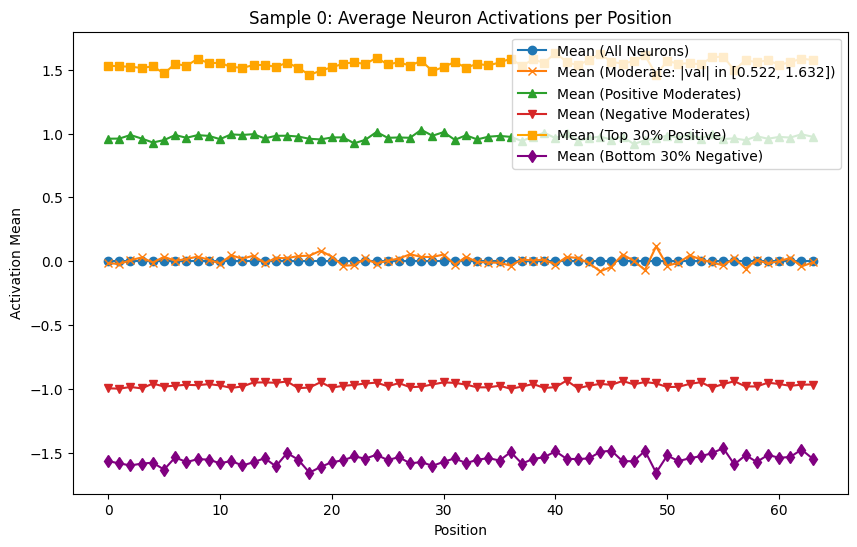

Plotted sample 0


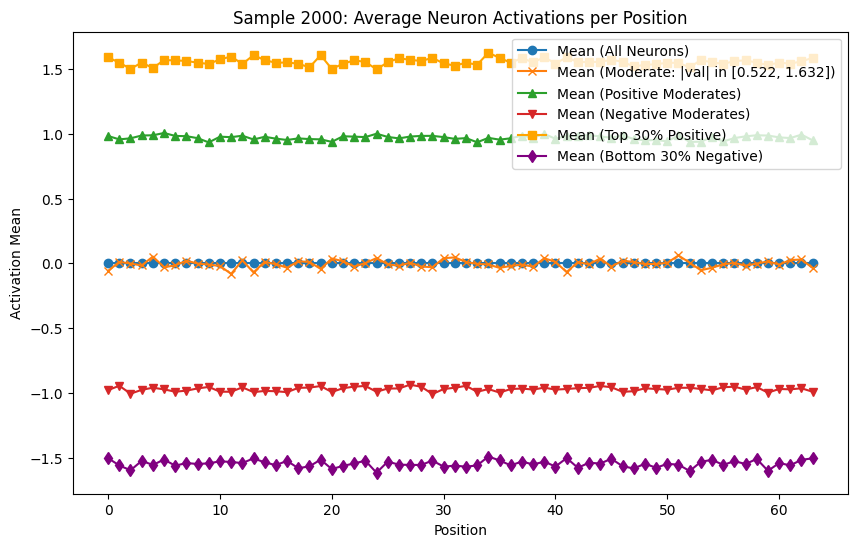

Plotted sample 2000


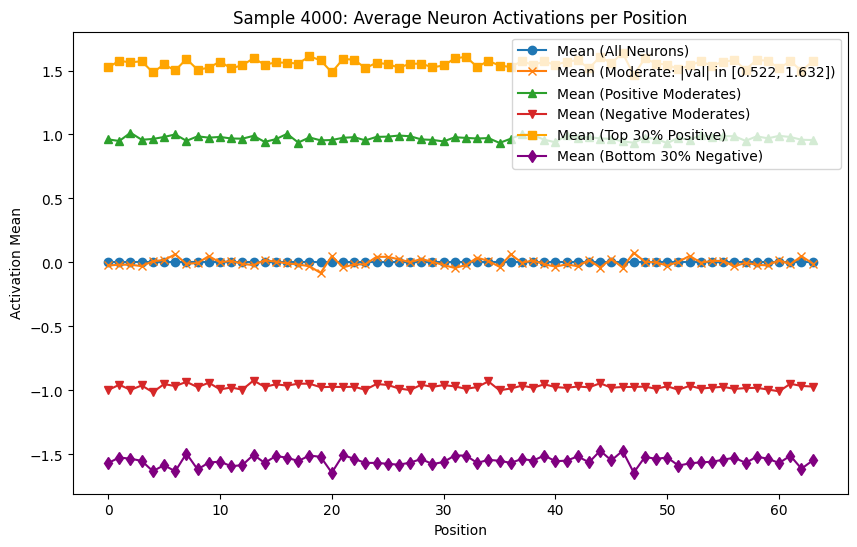

Plotted sample 4000


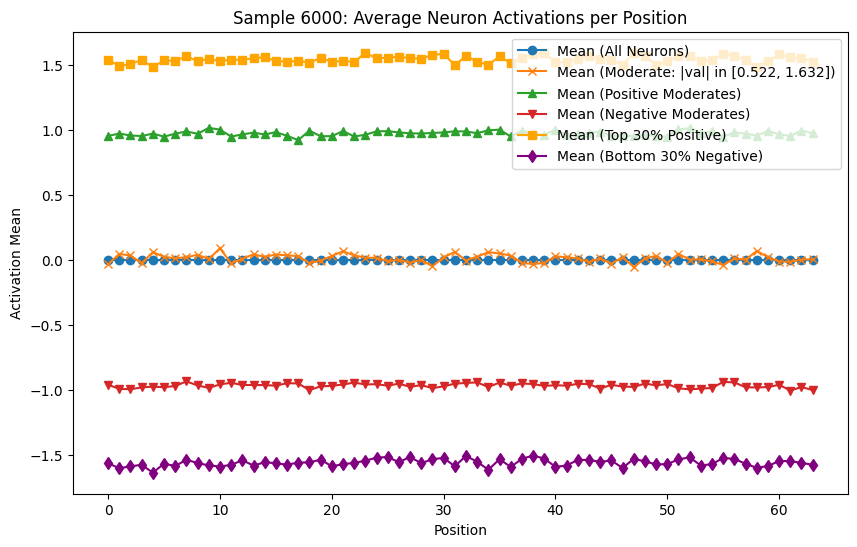

Plotted sample 6000


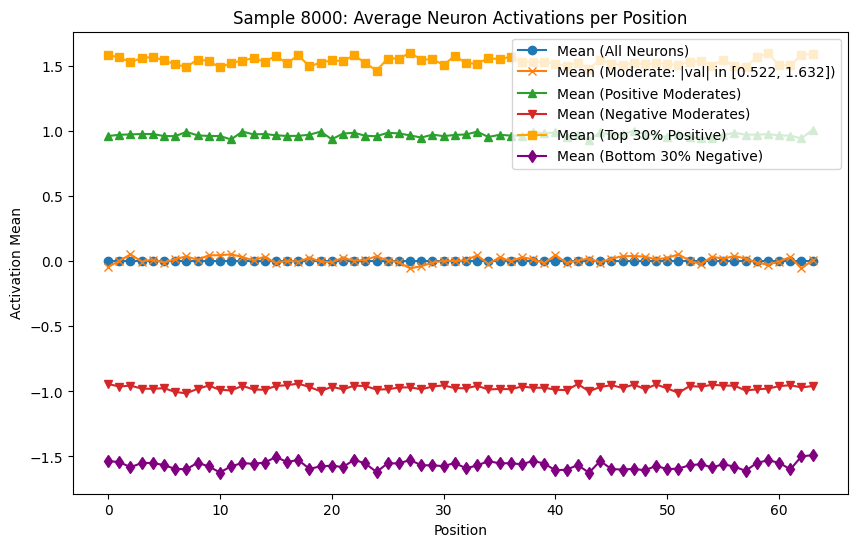

Plotted sample 8000


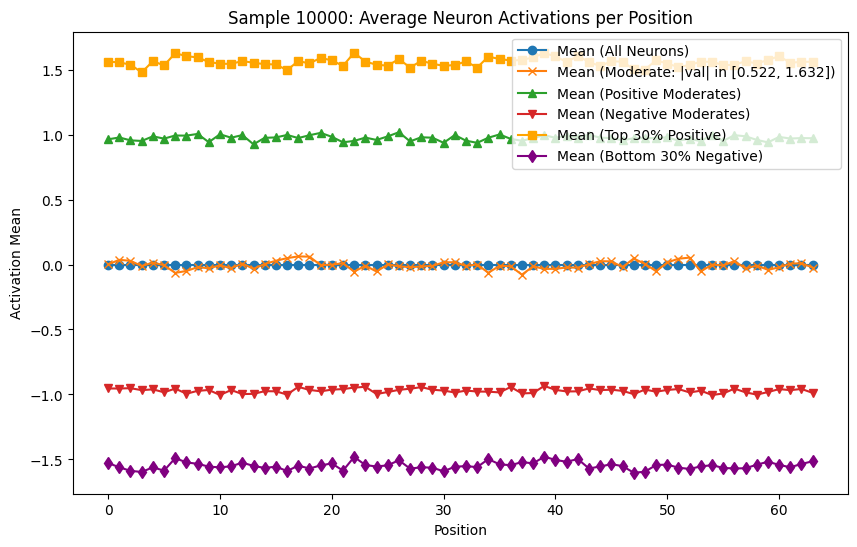

Plotted sample 10000


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------- Improved Activation Statistics Plotting ----------------
def plot_activation_statistics_improved(act='blocks.0.ln2.hook_normalized',
                                        lower_q=0.70, upper_q=0.95, sample_mod=2000):
    """
    Computes per-position average activations for various neuron subsets and plots them 
    for selected samples. Includes averages for the top 30% positive neurons and 
    bottom 30% negative neurons.
    
    Parameters:
      act (str): The key in cache to use for activations.
      lower_q (float): Lower quantile for filtering (default=0.70).
      upper_q (float): Upper quantile for filtering (default=0.95).
      sample_mod (int): Plot every sample index that is a multiple of this value.
    """
    # Get activations with shape: (batch, ctx, neurons)
    activations = cache[act]
    activations = activations.cpu().numpy()

    num_samples, n_positions, n_neurons = activations.shape
    print("Activations shape:", activations.shape)
    
    # Flatten (batch, ctx) to get X, and compute thresholds using the given quantiles.
    X = activations.reshape(-1, n_neurons)
    neurons_mean_val = X.mean(axis=0) 
    positive_neurons =  neurons_mean_val[neurons_mean_val>0]
    negative_neurons =  neurons_mean_val[neurons_mean_val<0]

    lower_thresh = np.quantile(X, lower_q, axis=0).mean()
    upper_thresh = np.quantile(X, upper_q, axis=0).mean()
    print(f"Lower threshold (quantile {lower_q}): {lower_thresh:.3f}")
    print(f"Upper threshold (quantile {upper_q}): {upper_thresh:.3f}")
    
    # For each sample, compute per-position averages
    for i in range(num_samples):
        sample = activations[i]  # shape: (n_positions, n_neurons)
        positions = np.arange(n_positions)
    
        avg_all = []          # Mean over all neurons.
        avg_mod = []          # Mean over neurons with |x| in [lower_thresh, upper_thresh]
        avg_pos_mod = []      # Mean over positive neurons in moderate range.
        avg_neg_mod = []      # Mean over negative neurons in moderate range.
        avg_top_30_pos = []   # Mean over top 30% positive neurons.
        avg_bottom_30_neg = []  # Mean over bottom 30% negative neurons.
    
        for pos_vals in sample:
            # Mean over all neurons.
            avg_all.append(pos_vals.mean())
            
            # Select neurons whose absolute activation is between lower_thresh and upper_thresh.
            sel_mod = pos_vals[(np.abs(pos_vals) >= lower_thresh) & (np.abs(pos_vals) <= upper_thresh)]
            avg_mod.append(sel_mod.mean() if sel_mod.size > 0 else 0)
            
            # For positive moderate neurons.
            pos_mod = pos_vals[(pos_vals >= lower_thresh) & (pos_vals <= upper_thresh)]
            avg_pos_mod.append(pos_mod.mean() if pos_mod.size > 0 else 0)
            
            # For negative moderate neurons.
            neg_mod = pos_vals[(pos_vals <= -lower_thresh) & (pos_vals >= -upper_thresh)]
            avg_neg_mod.append(neg_mod.mean() if neg_mod.size > 0 else 0)
            
            # For top 30% positive neurons.
            pos_vals_sorted = np.sort(pos_vals[pos_vals > 0])  # Sort positive values
            top_30_idx = int(len(pos_vals_sorted) * 0.7)  # Index for top 30%
            top_30 = pos_vals_sorted[top_30_idx:] if len(pos_vals_sorted) > 0 else []
            avg_top_30_pos.append(np.mean(top_30) if len(top_30) > 0 else 0)
            
            # For bottom 30% negative neurons.
            neg_vals_sorted = np.sort(pos_vals[pos_vals < 0])  # Sort negative values
            bottom_30_idx = int(len(neg_vals_sorted) * 0.3)  # Index for bottom 30%
            bottom_30 = neg_vals_sorted[:bottom_30_idx] if len(neg_vals_sorted) > 0 else []
            avg_bottom_30_neg.append(np.mean(bottom_30) if len(bottom_30) > 0 else 0)
    
        avg_all = np.array(avg_all)
        avg_mod = np.array(avg_mod)
        avg_pos_mod = np.array(avg_pos_mod)
        avg_neg_mod = np.array(avg_neg_mod)
        avg_top_30_pos = np.array(avg_top_30_pos)
        avg_bottom_30_neg = np.array(avg_bottom_30_neg)
    
        if i % sample_mod == 0:
            plt.figure(figsize=(10, 6))
            plt.plot(positions, avg_all, marker='o', label='Mean (All Neurons)')
            plt.plot(positions, avg_mod, marker='x', label=f'Mean (Moderate: |val| in [{lower_thresh:.3f}, {upper_thresh:.3f}])')
            plt.plot(positions, avg_pos_mod, marker='^', label='Mean (Positive Moderates)')
            plt.plot(positions, avg_neg_mod, marker='v', label='Mean (Negative Moderates)')
            plt.plot(positions, avg_top_30_pos, marker='s', label='Mean (Top 30% Positive)', color='orange')
            plt.plot(positions, avg_bottom_30_neg, marker='d', label='Mean (Bottom 30% Negative)', color='purple')
            plt.xlabel('Position')
            plt.ylabel('Activation Mean')
            plt.title(f'Sample {i}: Average Neuron Activations per Position')
            plt.legend()
            plt.show()
            print(f"Plotted sample {i}")

# Example call:
plot_activation_statistics_improved(act='blocks.0.ln2.hook_normalized', lower_q=0.70, upper_q=0.95)

In [ ]:
import matplotlib.pyplot as plt

# ---------------- Improved Activation Statistics Plotting ----------------
def plot_activation_statistics_improved(act='blocks.0.ln2.hook_normalized',
                                        lower_q=0.70, upper_q=0.95, sample_mod=2000):
    """
    Computes per-position average activations for various neuron subsets and plots them 
    for selected samples. Instead of thresholding with a single quantile, neurons are 
    restricted to those with absolute activations between the lower and upper quantile thresholds.
    
    This aims to exclude weak neurons (which induce noise) and extremely strong neurons 
    (which are too few), focusing on moderately strong activations.
    
    Parameters:
      act (str): The key in cache to use for activations.
      lower_q (float): Lower quantile for filtering (default=0.70).
      upper_q (float): Upper quantile for filtering (default=0.95).
      sample_mod (int): Plot every sample index that is a multiple of this value.
    """
    # Get activations with shape: (batch, ctx, neurons)
    activations = cache[act]
    if hasattr(activations, "cpu"):
        activations = activations.cpu().numpy()

    num_samples, n_positions, n_neurons = activations.shape
    print("Activations shape:", activations.shape)
    
    # Flatten (batch, ctx) to get X, and compute thresholds using the given quantiles.
    X = activations.reshape(-1, n_neurons)
    lower_thresh = np.quantile(X, lower_q, axis=0).mean()
    upper_thresh = np.quantile(X, upper_q, axis=0).mean()
    print(f"Lower threshold (quantile {lower_q}): {lower_thresh:.3f}")
    print(f"Upper threshold (quantile {upper_q}): {upper_thresh:.3f}")
    
    # For each sample, compute per-position averages
    for i in range(num_samples):
        sample = activations[i]  # shape: (n_positions, n_neurons)
        positions = np.arange(n_positions)
    
        avg_all = []          # Mean over all neurons.
        avg_mod = []          # Mean over neurons with |x| in [lower_thresh, upper_thresh]
        avg_pos_mod = []      # Mean over positive neurons in moderate range.
        avg_neg_mod = []      # Mean over negative neurons in moderate range.
    
        for pos_vals in sample:
            # Mean over all neurons.
            avg_all.append(pos_vals.mean())
            
            # Select neurons whose absolute activation is between lower_thresh and upper_thresh.
            sel_mod = pos_vals[(np.abs(pos_vals) >= lower_thresh) & (np.abs(pos_vals) <= upper_thresh)]
            avg_mod.append(sel_mod.mean() if sel_mod.size > 0 else 0)
            
            # For positive moderate neurons.
            pos_mod = pos_vals[(pos_vals >= lower_thresh) & (pos_vals <= upper_thresh)]
            avg_pos_mod.append(pos_mod.mean() if pos_mod.size > 0 else 0)
            
            # For negative moderate neurons.
            neg_mod = pos_vals[(pos_vals <= -lower_thresh) & (pos_vals >= -upper_thresh)]
            avg_neg_mod.append(neg_mod.mean() if neg_mod.size > 0 else 0)
    
        avg_all = np.array(avg_all)
        avg_mod = np.array(avg_mod)
        avg_pos_mod = np.array(avg_pos_mod)
        avg_neg_mod = np.array(avg_neg_mod)
    
        if i % sample_mod == 0:
            plt.figure(figsize=(10, 6))
            plt.plot(positions, avg_all, marker='o', label='Mean (All Neurons)')
            plt.plot(positions, avg_mod, marker='x', label=f'Mean (Moderate: |val| in [{lower_thresh:.3f}, {upper_thresh:.3f}])')
            plt.plot(positions, avg_pos_mod, marker='^', label='Mean (Positive Moderates)')
            plt.plot(positions, avg_neg_mod, marker='v', label='Mean (Negative Moderates)')
            plt.xlabel('Position')
            plt.ylabel('Activation Mean')
            plt.title(f'Sample {i}: Average Neuron Activations per Position')
            plt.legend()
            plt.show()
            print(f"Plotted sample {i}")

# Example call:
plot_activation_statistics_improved(act='blocks.0.ln2.hook_normalized', lower_q=0.70, upper_q=0.95)

Activations shape: (10240, 64, 1024)
Lower threshold (quantile 0.7): 0.522
Upper threshold (quantile 0.95): 1.632


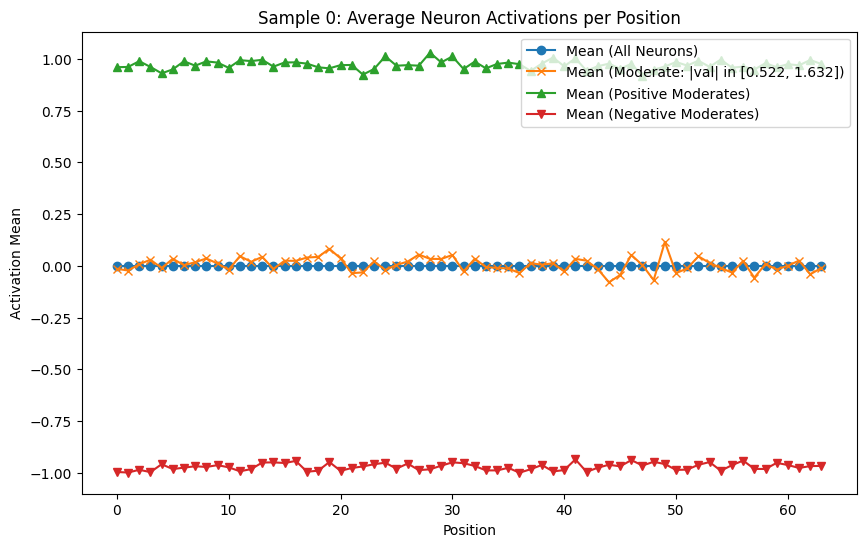

Plotted sample 0


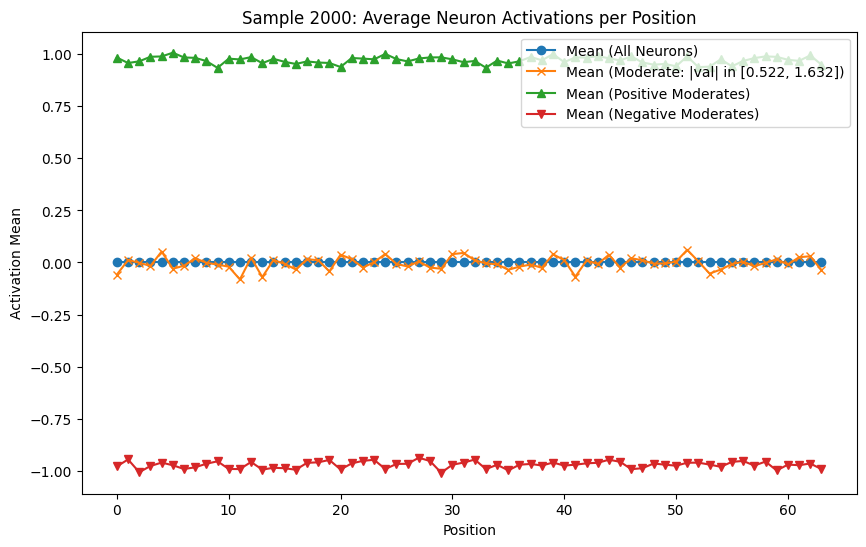

Plotted sample 2000


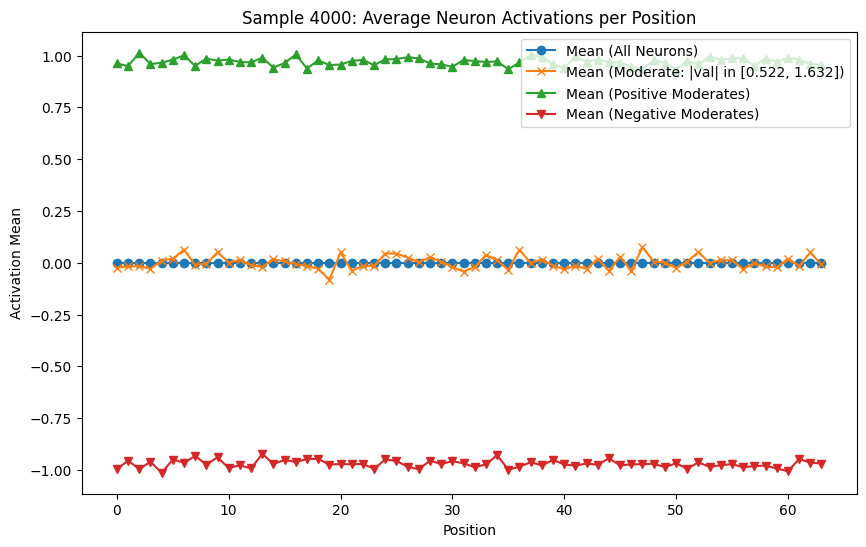

Plotted sample 4000


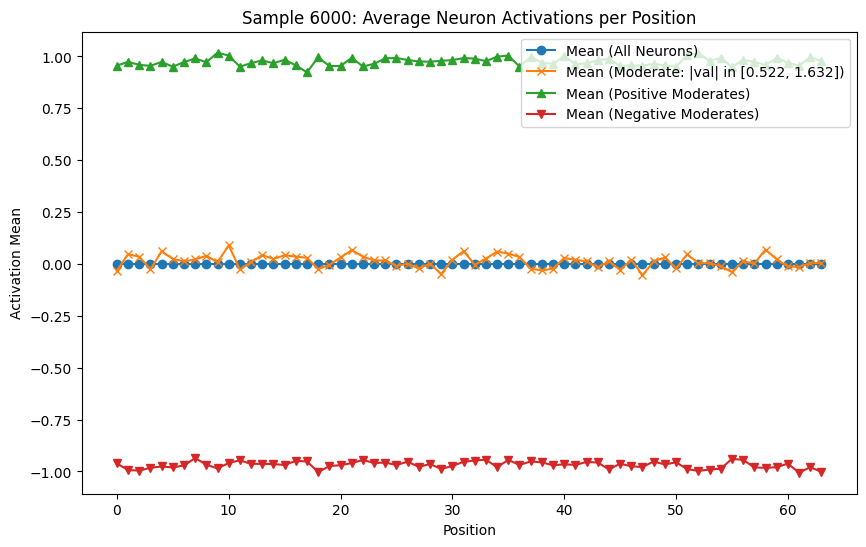

Plotted sample 6000


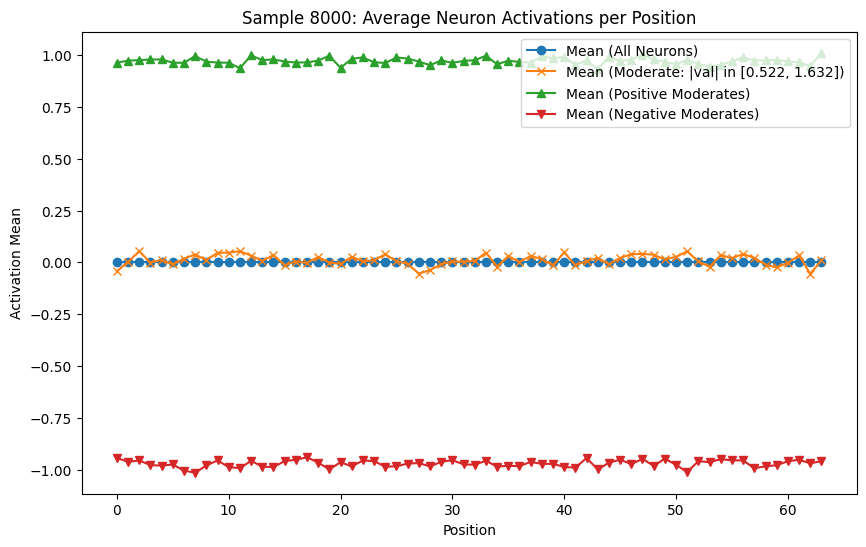

Plotted sample 8000


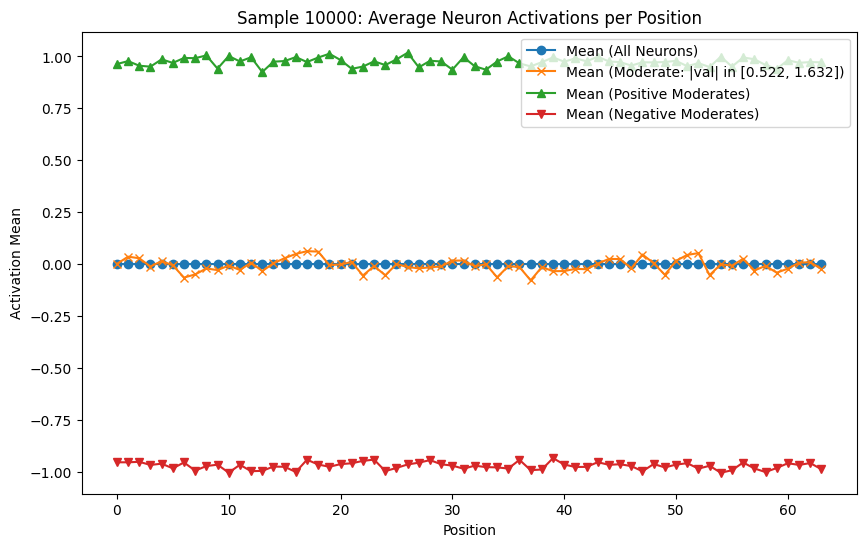

Plotted sample 10000


In [17]:
import matplotlib.pyplot as plt

# ---------------- Improved Activation Statistics Plotting ----------------
def plot_activation_statistics_improved(act='blocks.0.ln2.hook_normalized',
                                        lower_q=0.70, upper_q=0.95, sample_mod=2000):
    """
    Computes per-position average activations for various neuron subsets and plots them 
    for selected samples. Instead of thresholding with a single quantile, neurons are 
    restricted to those with absolute activations between the lower and upper quantile thresholds.
    
    This aims to exclude weak neurons (which induce noise) and extremely strong neurons 
    (which are too few), focusing on moderately strong activations.
    
    Parameters:
      act (str): The key in cache to use for activations.
      lower_q (float): Lower quantile for filtering (default=0.70).
      upper_q (float): Upper quantile for filtering (default=0.95).
      sample_mod (int): Plot every sample index that is a multiple of this value.
    """
    # Get activations with shape: (batch, ctx, neurons)
    activations = cache[act]
    if hasattr(activations, "cpu"):
        activations = activations.cpu().numpy()

    num_samples, n_positions, n_neurons = activations.shape
    print("Activations shape:", activations.shape)
    
    # Flatten (batch, ctx) to get X, and compute thresholds using the given quantiles.
    X = activations.reshape(-1, n_neurons)
    lower_thresh = np.quantile(X, lower_q, axis=0).mean()
    upper_thresh = np.quantile(X, upper_q, axis=0).mean()
    print(f"Lower threshold (quantile {lower_q}): {lower_thresh:.3f}")
    print(f"Upper threshold (quantile {upper_q}): {upper_thresh:.3f}")
    
    # For each sample, compute per-position averages
    for i in range(num_samples):
        sample = activations[i]  # shape: (n_positions, n_neurons)
        positions = np.arange(n_positions)
    
        avg_all = []          # Mean over all neurons.
        avg_mod = []          # Mean over neurons with |x| in [lower_thresh, upper_thresh]
        avg_pos_mod = []      # Mean over positive neurons in moderate range.
        avg_neg_mod = []      # Mean over negative neurons in moderate range.
    
        for pos_vals in sample:
            # Mean over all neurons.
            avg_all.append(pos_vals.mean())
            
            # Select neurons whose absolute activation is between lower_thresh and upper_thresh.
            sel_mod = pos_vals[(np.abs(pos_vals) >= lower_thresh) & (np.abs(pos_vals) <= upper_thresh)]
            avg_mod.append(sel_mod.mean() if sel_mod.size > 0 else 0)
            
            # For positive moderate neurons.
            pos_mod = pos_vals[(pos_vals >= lower_thresh) & (pos_vals <= upper_thresh)]
            avg_pos_mod.append(pos_mod.mean() if pos_mod.size > 0 else 0)
            
            # For negative moderate neurons.
            neg_mod = pos_vals[(pos_vals <= -lower_thresh) & (pos_vals >= -upper_thresh)]
            avg_neg_mod.append(neg_mod.mean() if neg_mod.size > 0 else 0)
    
        avg_all = np.array(avg_all)
        avg_mod = np.array(avg_mod)
        avg_pos_mod = np.array(avg_pos_mod)
        avg_neg_mod = np.array(avg_neg_mod)
    
        if i % sample_mod == 0:
            plt.figure(figsize=(10, 6))
            plt.plot(positions, avg_all, marker='o', label='Mean (All Neurons)')
            plt.plot(positions, avg_mod, marker='x', label=f'Mean (Moderate: |val| in [{lower_thresh:.3f}, {upper_thresh:.3f}])')
            plt.plot(positions, avg_pos_mod, marker='^', label='Mean (Positive Moderates)')
            plt.plot(positions, avg_neg_mod, marker='v', label='Mean (Negative Moderates)')
            plt.xlabel('Position')
            plt.ylabel('Activation Mean')
            plt.title(f'Sample {i}: Average Neuron Activations per Position')
            plt.legend()
            plt.show()
            print(f"Plotted sample {i}")

# Example call:
plot_activation_statistics_improved(act='blocks.0.ln2.hook_normalized', lower_q=0.70, upper_q=0.95)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from sklearn.linear_model import LogisticRegression


N_SAMPLES = 1_024
BATCH_SIZE = N_SAMPLES
D_VOCAB = 10_000
train_dataset = torch.randint(low=0, high=D_VOCAB, size=(N_SAMPLES, N_CTX), device=device)
test_dataset = torch.randint(low=0, high=D_VOCAB, size=(N_SAMPLES, N_CTX), device=device)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

################ Data
cfg = HookedTransformerConfig(
    n_layers=1,
    d_model=2048,
    d_head=2048,
    n_heads=12,
    d_mlp=2048,
    d_vocab=D_VOCAB,
    n_ctx=N_CTX,
    act_fn='relu',
    normalization_type='LN',
    device=device,
    use_hook_mlp_in=True
)

lit_model = LitTransformer(cfg, train_loader, test_loader)
lit_model.to(device)
freeze_lns(lit_model.model, l=0)
model = lit_model.model
freeze_lns(model)
logits, cache = model.run_with_cache(test_loader.dataset)


def plot_activation_statistics_improved(act='blocks.0.ln2.hook_normalized',
                                        lower_q=0.70, upper_q=0.95, sample_mod=2000):
    """
    Computes per-position average activations for various neuron subsets and plots them 
    for selected samples. Instead of thresholding with a single quantile, neurons are 
    restricted to those with absolute activations between the lower and upper quantile thresholds.
    
    This aims to exclude weak neurons (which induce noise) and extremely strong neurons 
    (which are too few), focusing on moderately strong activations.
    
    Parameters:
      act (str): The key in cache to use for activations.
      lower_q (float): Lower quantile for filtering (default=0.70).
      upper_q (float): Upper quantile for filtering (default=0.95).
      sample_mod (int): Plot every sample index that is a multiple of this value.
    """
    # Get activations with shape: (batch, ctx, neurons)
    activations = cache[act]
    activations = activations.cpu().numpy()

    num_samples, n_positions, n_neurons = activations.shape
    print("Activations shape:", activations.shape)
    
    # Flatten (batch, ctx) to get X, and compute thresholds using the given quantiles.
    X = activations.reshape(-1, n_neurons)
    lower_thresh = np.quantile(X, lower_q, axis=0).mean()
    upper_thresh = np.quantile(X, upper_q, axis=0).mean()
    print(f"Lower threshold (quantile {lower_q}): {lower_thresh:.3f}")
    print(f"Upper threshold (quantile {upper_q}): {upper_thresh:.3f}")
    
    # For each sample, compute per-position averages
    for i in range(num_samples):
        sample = activations[i]  # shape: (n_positions, n_neurons)
        positions = np.arange(n_positions)
    
        avg_all = []          # Mean over all neurons.
        avg_mod = []          # Mean over neurons with |x| in [lower_thresh, upper_thresh]
        avg_pos_mod = []      # Mean over positive neurons in moderate range.
        avg_neg_mod = []      # Mean over negative neurons in moderate range.
    
        for pos_vals in sample:
            # Mean over all neurons.
            avg_all.append(pos_vals.mean())
            
            # Select neurons whose absolute activation is between lower_thresh and upper_thresh.
            sel_mod = pos_vals[(np.abs(pos_vals) >= lower_thresh) & (np.abs(pos_vals) <= upper_thresh)]
            avg_mod.append(sel_mod.mean() if sel_mod.size > 0 else 0)
            
            # For positive moderate neurons.
            pos_mod = pos_vals[(pos_vals >= lower_thresh) & (pos_vals <= upper_thresh)]
            avg_pos_mod.append(pos_mod.mean() if pos_mod.size > 0 else 0)
            
            # For negative moderate neurons.
            neg_mod = pos_vals[(pos_vals <= -lower_thresh) & (pos_vals >= -upper_thresh)]
            avg_neg_mod.append(neg_mod.mean() if neg_mod.size > 0 else 0)
    
        avg_all = np.array(avg_all)
        avg_mod = np.array(avg_mod)
        avg_pos_mod = np.array(avg_pos_mod)
        avg_neg_mod = np.array(avg_neg_mod)
    
        if i % sample_mod == 0:
            plt.figure(figsize=(10, 6))
            plt.plot(positions, avg_all, marker='o', label='Mean (All Neurons)')
            plt.plot(positions, avg_mod, marker='x', label=f'Mean (Moderate: |val| in [{lower_thresh:.3f}, {upper_thresh:.3f}])')
            plt.plot(positions, avg_pos_mod, marker='^', label='Mean (Positive Moderates)')
            plt.plot(positions, avg_neg_mod, marker='v', label='Mean (Negative Moderates)')
            plt.xlabel('Position')
            plt.ylabel('Activation Mean')
            plt.title(f'Sample {i}: Average Neuron Activations per Position')
            plt.legend()
            plt.show()
            print(f"Plotted sample {i}")

# Example call:
plot_activation_statistics_improved(act='blocks.0.ln2.hook_normalized', lower_q=0.90, upper_q=0.95)

In [ ]:
test_dataset 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

BATCH_SIZE = 1024
N_SAMPLES = 1024
D_VOCAB = 50
train_dataset = torch.randint(low=0, high=D_VOCAB, size=(N_SAMPLES, N_CTX), device=device)
test_dataset = torch.randint(low=0, high=D_VOCAB, size=(N_SAMPLES, N_CTX), device=device)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

################ Data
cfg = HookedTransformerConfig(
    n_layers=1,
    d_model=2048,
    d_head=2048,
    n_heads=1,
    d_mlp=2048,
    d_vocab=D_VOCAB,
    n_ctx=N_CTX,
    act_fn='relu',
    normalization_type='LN',
    device=device,
    use_hook_mlp_in=True
)

lit_model = LitTransformer(cfg, train_loader, test_loader)
lit_model.to(device)
freeze_lns(lit_model.model, l=0)
model = lit_model.model
freeze_lns(model)
logits, cache = model.run_with_cache(test_loader.dataset)

def plot_activation_statistics(q_thresh=0.95, act='blocks.0.hook_resid_mid'):
    """
    Computes per-position average activations for various neuron subsets
    and plots them for selected samples.

    Parameters:
      q_thresh (float): The quantile to compute the threshold (default=0.95).
      sample_mod (int): Plot every sample index that is a multiple of this value.
    """
    # Get all activations with shape: (batch, ctx, neurons)
    activations = cache[act]
    activations = activations.cpu().numpy()

    num_samples, n_positions, n_neurons = activations.shape
    print("Activations shape:", activations.shape)

    # Flatten the batch and context dimensions to get X of shape (batch*ctx, neurons)
    X = activations.reshape(-1, n_neurons)
    threshold = np.quantile(X, q_thresh, axis=0).mean()
    print(f"Threshold (quantile {q_thresh}): {threshold:.3f}")

    # For each sample, compute per-position averages for various neuron subsets.
    for i in range(num_samples):
        sample = activations[i]  # shape: (n_positions, n_neurons)
        positions = np.arange(n_positions)

        avg_all = []         # Average over all neurons.
        avg_filtered = []    # Average over neurons with |value| > threshold.
        avg_pos = []         # Average over only positive neurons.
        avg_neg = []         # Average over only negative neurons.
        avg_pos_large = []   # Average over positive neurons with value > threshold.
        avg_neg_large = []   # Average over negative neurons with value < -threshold.

        for pos_vals in sample:
            # Mean over all neurons.
            avg_all.append(pos_vals.mean())

            # Average over neurons with |value| > threshold.
            sel_filtered = pos_vals[np.abs(pos_vals) > threshold]
            avg_filtered.append(sel_filtered.mean() if sel_filtered.size > 0 else 0)

            # Average over positive neurons.
            pos_only = pos_vals[pos_vals > 0]
            avg_pos.append(pos_only.mean() if pos_only.size > 0 else 0)

            # Average over negative neurons.
            neg_only = pos_vals[pos_vals < 0]
            avg_neg.append(neg_only.mean() if neg_only.size > 0 else 0)

            # Average over positive neurons with value > threshold.
            pos_large = pos_vals[pos_vals > threshold]
            avg_pos_large.append(pos_large.mean() if pos_large.size > 0 else 0)

            # Average over negative neurons with value < -threshold.
            neg_large = pos_vals[pos_vals < -threshold]
            avg_neg_large.append(neg_large.mean() if neg_large.size > 0 else 0)

        avg_all = np.array(avg_all)
        avg_filtered = np.array(avg_filtered)
        avg_pos = np.array(avg_pos)
        avg_neg = np.array(avg_neg)
        avg_pos_large = np.array(avg_pos_large)
        avg_neg_large = np.array(avg_neg_large)

        if i % 2_000 == 0:
            plt.figure(figsize=(10, 6))
            plt.plot(positions, avg_all, marker='o', label='Mean (All Neurons)')
            plt.plot(positions, avg_filtered, marker='x', label=f'Mean (|val|>{threshold:.3f})')
            plt.plot(positions, avg_pos, marker='^', label='Mean (Positive Neurons)')
            plt.plot(positions, avg_neg, marker='v', label='Mean (Negative Neurons)')
            plt.plot(positions, avg_pos_large, marker='s', label=f'Mean (Pos > {threshold:.3f})')
            plt.plot(positions, avg_neg_large, marker='d', label=f'Mean (Neg < -{threshold:.3f})')
            plt.xlabel('Position')
            plt.ylabel('Activation Mean')
            plt.title(f'Sample {i}: Average Neuron Activations per Position')
            plt.legend()
            plt.show()
            print(f"Plotted sample {i}")

# Example call:
plot_activation_statistics(q_thresh=0.70, act='blocks.0.ln2.hook_normalized')

In [ ]:
plot_activation_statistics(q_thresh=0.50, act='blocks.0.ln2.hook_normalized')

In [ ]:
cache

In [ ]:
plot_activation_statistics(q_thresh=0.99, act='blocks.0.ln2.hook_normalized')

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

BATCH_SIZE = 1_024
N_SAMPLES = 1_024
D_VOCAB = 5_000
train_dataset = torch.randint(low=0, high=D_VOCAB, size=(N_SAMPLES, N_CTX), device=device)
test_dataset = torch.randint(low=0, high=D_VOCAB, size=(N_SAMPLES, N_CTX), device=device)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

################ Data
cfg = HookedTransformerConfig(
    n_layers=1,
    d_model=1024,
    d_head=1024,
    n_heads=1,
    d_mlp=4096,
    d_vocab=D_VOCAB,
    n_ctx=N_CTX,
    act_fn='relu',
    normalization_type='LN',
    device=device,
    use_hook_mlp_in=True
)

lit_model = LitTransformer(cfg, train_loader, test_loader)
lit_model.to(device)
freeze_lns(lit_model.model, l=0)
model = lit_model.model
freeze_lns(model)
logits, cache = model.run_with_cache(test_loader.dataset)

def plot_activation_statistics(q_thresh=0.95):
    """
    Computes per-position average activations for various neuron subsets
    and plots them for selected samples.

    Parameters:
      q_thresh (float): The quantile to compute the threshold (default=0.95).
      sample_mod (int): Plot every sample index that is a multiple of this value.
    """
    # Get all activations with shape: (batch, ctx, neurons)
    activations = cache['blocks.0.ln2.hook_normalized']
    if hasattr(activations, "cpu"):
        activations = activations.cpu().numpy()

    num_samples, n_positions, n_neurons = activations.shape
    print("Activations shape:", activations.shape)

    # Flatten the batch and context dimensions to get X of shape (batch*ctx, neurons)
    X = activations.reshape(-1, n_neurons)
    threshold = np.quantile(X, q_thresh, axis=0).mean()
    print(f"Threshold (quantile {q_thresh}): {threshold:.3f}")

    # For each sample, compute per-position averages for various neuron subsets.
    for i in range(num_samples):
        sample = activations[i]  # shape: (n_positions, n_neurons)
        positions = np.arange(n_positions)

        avg_all = []         # Average over all neurons.
        avg_filtered = []    # Average over neurons with |value| > threshold.
        avg_pos = []         # Average over only positive neurons.
        avg_neg = []         # Average over only negative neurons.
        avg_pos_large = []   # Average over positive neurons with value > threshold.
        avg_neg_large = []   # Average over negative neurons with value < -threshold.

        for pos_vals in sample:
            # Mean over all neurons.
            avg_all.append(pos_vals.mean())

            # Average over neurons with |value| > threshold.
            sel_filtered = pos_vals[np.abs(pos_vals) > threshold]
            avg_filtered.append(sel_filtered.mean() if sel_filtered.size > 0 else 0)

            # Average over positive neurons.
            pos_only = pos_vals[pos_vals > 0]
            avg_pos.append(pos_only.mean() if pos_only.size > 0 else 0)

            # Average over negative neurons.
            neg_only = pos_vals[pos_vals < 0]
            avg_neg.append(neg_only.mean() if neg_only.size > 0 else 0)

            # Average over positive neurons with value > threshold.
            pos_large = pos_vals[pos_vals > threshold]
            avg_pos_large.append(pos_large.mean() if pos_large.size > 0 else 0)

            # Average over negative neurons with value < -threshold.
            neg_large = pos_vals[pos_vals < -threshold]
            avg_neg_large.append(neg_large.mean() if neg_large.size > 0 else 0)

        avg_all = np.array(avg_all)
        avg_filtered = np.array(avg_filtered)
        avg_pos = np.array(avg_pos)
        avg_neg = np.array(avg_neg)
        avg_pos_large = np.array(avg_pos_large)
        avg_neg_large = np.array(avg_neg_large)

        if i % 1_000 == 0:
            plt.figure(figsize=(10, 6))
            plt.plot(positions, avg_all, marker='o', label='Mean (All Neurons)')
            plt.plot(positions, avg_filtered, marker='x', label=f'Mean (|val|>{threshold:.3f})')
            plt.plot(positions, avg_pos, marker='^', label='Mean (Positive Neurons)')
            plt.plot(positions, avg_neg, marker='v', label='Mean (Negative Neurons)')
            plt.plot(positions, avg_pos_large, marker='s', label=f'Mean (Pos > {threshold:.3f})')
            plt.plot(positions, avg_neg_large, marker='d', label=f'Mean (Neg < -{threshold:.3f})')
            plt.xlabel('Position')
            plt.ylabel('Activation Mean')
            plt.title(f'Sample {i}: Average Neuron Activations per Position')
            plt.legend()
            plt.show()
            print(f"Plotted sample {i}")

# Example call:
plot_activation_statistics(q_thresh=0.95)

In [ ]:
BATCH_SIZE = 1_024
N_SAMPLES = 1_024
D_VOCAB = 5_000
train_dataset = torch.randint(low=0, high=D_VOCAB, size=(N_SAMPLES, N_CTX), device=device)
test_dataset = torch.randint(low=0, high=D_VOCAB, size=(N_SAMPLES, N_CTX), device=device)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

################ Data

In [ ]:
import numpy as np
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

# Get all activations with shape: (batch, ctx, neurons)
activations = cache['blocks.0.ln2.hook_normalized']
if hasattr(activations, "cpu"):
    activations = activations.cpu().numpy()

num_samples, n_positions, n_neurons = activations.shape
print("Activations shape:", activations.shape)

# Prepare the dataset for training:
#  - Flatten the batch and context dimensions so that X has shape (batch * ctx, neurons).
#  - Create labels for each position (absolute positions remain the same within a sample).
X = activations.reshape(-1, n_neurons)
q95 = np.quantile(X, 0.95, axis=0).mean()
y = np.tile(np.arange(n_positions), num_samples)  # shape: (batch * ctx,)

# Train a linear classifier to predict absolute position.
classifier = LogisticRegression(
    max_iter=1000, multi_class='multinomial', solver='lbfgs'
)
classifier.fit(X, y)

# For each sample, predict positions and plot the results.
for i in range(num_samples):
    sample = activations[i]  # shape: (n_positions, n_neurons)
    true_positions = np.arange(n_positions)
    predicted_positions = classifier.predict(sample)
    if i % 1000 == 0: 
        plt.figure(figsize=(8, 4))
        plt.plot(true_positions, predicted_positions, marker='o', label='Predicted Position')
        plt.plot(true_positions, true_positions, linestyle='--', label='True Position')
        plt.xlabel('True Position')
        plt.ylabel('Predicted Position')
        plt.title(f'Sample {i}: Linear Classifier Prediction of Absolute Position')
        plt.legend()
        plt.show()
    
    accuracy = classifier.score(sample, true_positions)
    print(f"Sample {i} - Classification Accuracy: {accuracy:.4f}")

In [ ]:
import numpy as np
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

# Get all activations with shape: (batch, ctx, neurons)
activations = cache['blocks.0.ln2.hook_normalized']
if hasattr(activations, "cpu"):
    activations = activations.cpu().numpy()

num_samples, n_positions, n_neurons = activations.shape
print("Activations shape:", activations.shape)

# Prepare the dataset for training:
#  - Flatten batch and context dimensions so that X has shape (batch * ctx, neurons).
#  - Create labels for each position.
X = activations.reshape(-1, n_neurons)
q95 = np.quantile(X, 0.95, axis=0).mean()
y = np.tile(np.arange(n_positions), num_samples)  # shape: (batch * ctx,)

# Train a linear classifier to predict absolute position.
classifier = LogisticRegression(
    max_iter=1000, multi_class='multinomial', solver='lbfgs'
)
classifier.fit(X, y)

# Set threshold for filtering based on absolute value.
threshold = q95

# Lists to store accuracy for each sample.
all_accs = []
filtered_accs = []

# For each sample, predict positions and compute accuracy on full and filtered activations.
for i in range(num_samples):
    sample = activations[i]  # shape: (n_positions, n_neurons)
    true_positions = np.arange(n_positions)

    # Accuracy on full activations.
    score_all = classifier.score(sample, true_positions)
    
    # Create a filtered sample: keep neuron if |value| > threshold, else set to zero.
    sample_filtered = np.where(np.abs(sample) > threshold, sample, 0)
    score_filtered = classifier.score(sample_filtered, true_positions)
    
    all_accs.append(score_all)
    filtered_accs.append(score_filtered)
    
    # Plot for select samples.
    predicted_positions = classifier.predict(sample)
    if i % 1000 == 0: 
        plt.figure(figsize=(8, 4))
        plt.plot(true_positions, predicted_positions, marker='o', label='Predicted Position')
        plt.plot(true_positions, true_positions, linestyle='--', label='True Position')
        plt.xlabel('True Position')
        plt.ylabel('Predicted Position')
        plt.title(f'Sample {i}: Linear Classifier Prediction of Absolute Position')
        plt.legend()
        plt.show()
    
    # print(f"Sample {i} - Accuracy All Neurons: {score_all:.4f}, Filtered (|val|>{threshold}): {score_filtered:.4f}")

# Compute average accuracies.
avg_all = np.mean(all_accs)
avg_filtered = np.mean(filtered_accs)
print(f"\nAverage Accuracy over all samples (All Neurons): {avg_all:.4f}")
print(f"Average Accuracy over all samples (Filtered |val|>{threshold}): {avg_filtered:.4f}")

# Plot a bar chart comparing the average accuracies.
plt.figure(figsize=(6, 4))
plt.bar(['All Neurons', f'Filtered (|val|>{threshold})'], [avg_all, avg_filtered], color=['blue', 'orange'])
plt.ylabel('Average Accuracy')
plt.title('Average Classification Accuracy')
plt.ylim(0, 1)
plt.show()

# Firday

In [ ]:
line(cache['blocks.0.ln2.hook_normalized'][0])

In [ ]:
# A weighter avg

In [ ]:
# ...existing code...

# Extract the tensor
tensor = cache['blocks.0.ln2.hook_normalized'][1]

# Apply the mask for absolute values between 0.5 and 1.2
mask = (tensor.abs() > 0.5) & (tensor.abs() < 1.5)

# Create separate masks for positive and negative values
positive_mask = mask & (tensor > 0)
negative_mask = mask & (tensor < 0)

# Compute the weighted average per position
positive_sum = tensor.masked_fill(~positive_mask, 0).sum(dim=1)
negative_sum = tensor.masked_fill(~negative_mask, 0).sum(dim=1)
positive_count = positive_mask.sum(dim=1)
negative_count = negative_mask.sum(dim=1)

# Avoid division by zero by replacing zero counts with NaN
positive_count = torch.where(positive_count == 0, torch.tensor(float('nan'), device=tensor.device), positive_count)
negative_count = torch.where(negative_count == 0, torch.tensor(float('nan'), device=tensor.device), negative_count)

# Compute weighted averages
weighted_avg_per_position = (
    0.7 * (positive_sum / positive_count) +
    0.3 * (negative_sum / negative_count)
)

# Handle positions where neither positive nor negative values exist
weighted_avg_per_position = torch.where(
    mask.any(dim=1),
    weighted_avg_per_position,
    torch.tensor(float('nan'), device=tensor.device)
)

# Plot the results
import matplotlib.pyplot as plt

positions = torch.arange(tensor.size(0)).cpu()  # Assuming positions correspond to the first dimension

plt.figure(figsize=(10, 6))
plt.plot(positions, weighted_avg_per_position.cpu(), label="Weighted Avg (0.6 Positive, 0.4 Negative)", color="purple")
plt.xlabel("Position")
plt.ylabel("Weighted Average Value")
plt.title("Weighted Neuron Averages Per Position (Filtered Range)")
plt.legend()
plt.grid()
plt.show()

# ...existing code...

In [ ]:
tensor = cache['blocks.0.ln2.hook_normalized'][0]

In [ ]:
cache['blocks.0.ln2.hook_scale'][0]

In [ ]:
cache['blocks.0.ln2.hook_scale']

In [ ]:
cache['ln_final.hook_scale'].shape

In [ ]:
model

In [ ]:
# ...existing code...

# Extract the tensor
tensor = cache['blocks.0.ln2.hook_normalized'][2]

# Apply the mask for absolute values between 0.5 and 1.5
mask = (tensor.abs() > 0.5) & (tensor.abs() < 1.5)

# Create separate masks for positive and negative values
positive_mask = mask & (tensor > 0)
negative_mask = mask & (tensor < 0)

# Count the number of filtered positive and negative neurons per position
positive_count_per_position = positive_mask.sum(dim=1)
negative_count_per_position = negative_mask.sum(dim=1)

# Compute the average per position for all filtered values
avg_per_position_filtered = torch.where(
    mask.any(dim=1),
    tensor.masked_fill(~mask, 0).sum(dim=1) / mask.sum(dim=1),
    torch.tensor(float('nan'), device=tensor.device)
)

# Compute the average per position for positive and negative filtered values
avg_positive_per_position_filtered = torch.where(
    positive_mask.any(dim=1),
    tensor.masked_fill(~positive_mask, 0).sum(dim=1) / positive_mask.sum(dim=1),
    torch.tensor(float('nan'), device=tensor.device)
)

avg_negative_per_position_filtered = torch.where(
    negative_mask.any(dim=1),
    tensor.masked_fill(~negative_mask, 0).sum(dim=1) / negative_mask.sum(dim=1),
    torch.tensor(float('nan'), device=tensor.device)
)

# Compute the non-filtered averages
avg_per_position_non_filtered = tensor.mean(dim=1)
avg_positive_per_position_non_filtered = torch.where(
    (tensor > 0).any(dim=1),
    tensor.masked_fill(tensor <= 0, 0).sum(dim=1) / (tensor > 0).sum(dim=1),
    torch.tensor(float('nan'), device=tensor.device)
)
avg_negative_per_position_non_filtered = torch.where(
    (tensor < 0).any(dim=1),
    tensor.masked_fill(tensor >= 0, 0).sum(dim=1) / (tensor < 0).sum(dim=1),
    torch.tensor(float('nan'), device=tensor.device)
)

# Plot the filtered data
import matplotlib.pyplot as plt

positions = torch.arange(tensor.size(0)).cpu()  # Assuming positions correspond to the first dimension

plt.figure(figsize=(10, 6))
plt.plot(positions, avg_per_position_filtered.cpu(), label="Avg (Filtered)", color="blue")
plt.plot(positions, avg_positive_per_position_filtered.cpu(), label="Avg Positive (Filtered)", color="green")
plt.plot(positions, avg_negative_per_position_filtered.cpu(), label="Avg Negative (Filtered)", color="red")
plt.bar(positions - 0.2, positive_count_per_position.cpu(), width=0.4, label="Positive Count (Filtered)", color="lightgreen", alpha=0.6)
plt.bar(positions + 0.2, negative_count_per_position.cpu(), width=0.4, label="Negative Count (Filtered)", color="lightcoral", alpha=0.6)
plt.xlabel("Position")
plt.ylabel("Value / Count")
plt.title("Filtered Neuron Averages and Counts Per Position")
plt.legend()
plt.grid()
plt.show()

# Plot the non-filtered data
plt.figure(figsize=(10, 6))
plt.plot(positions, avg_per_position_non_filtered.cpu(), label="Avg (Non-Filtered)", color="blue")
plt.plot(positions, avg_positive_per_position_non_filtered.cpu(), label="Avg Positive (Non-Filtered)", color="green")
plt.plot(positions, avg_negative_per_position_non_filtered.cpu(), label="Avg Negative (Non-Filtered)", color="red")
plt.xlabel("Position")
plt.ylabel("Average Value")
plt.title("Non-Filtered Neuron Averages Per Position")
plt.legend()
plt.grid()
plt.show()

# ...existing code...

In [ ]:
# ...existing code...

# Extract the tensor
tensor = cache['blocks.0.ln2.hook_normalized'][0]

# Apply the mask for absolute values between 0.5 and 1.5
mask = (tensor.abs() > 0.5) & (tensor.abs() < 1.5)

# Create separate masks for positive and negative values
positive_mask = mask & (tensor > 0)
negative_mask = mask & (tensor < 0)

# Count the number of filtered positive and negative neurons per position
positive_count_per_position = positive_mask.sum(dim=1)
negative_count_per_position = negative_mask.sum(dim=1)

# Compute the average per position for all filtered values
avg_per_position = torch.where(
    mask.any(dim=1),
    tensor.masked_fill(~mask, 0).sum(dim=1) / mask.sum(dim=1),
    torch.tensor(float('nan'), device=tensor.device)
)

# Compute the average per position for positive values
avg_positive_per_position = torch.where(
    positive_mask.any(dim=1),
    tensor.masked_fill(~positive_mask, 0).sum(dim=1) / positive_mask.sum(dim=1),
    torch.tensor(float('nan'), device=tensor.device)
)

# Compute the average per position for negative values
avg_negative_per_position = torch.where(
    negative_mask.any(dim=1),
    tensor.masked_fill(~negative_mask, 0).sum(dim=1) / negative_mask.sum(dim=1),
    torch.tensor(float('nan'), device=tensor.device)
)

# Plot the results
import matplotlib.pyplot as plt

positions = torch.arange(tensor.size(0)).cpu()  # Assuming positions correspond to the first dimension

plt.figure(figsize=(10, 6))

# Plot averages
plt.plot(positions, avg_per_position.cpu(), label="Avg (Filtered)", color="blue")
plt.plot(positions, avg_positive_per_position.cpu(), label="Avg Positive (Filtered)", color="green")
plt.plot(positions, avg_negative_per_position.cpu(), label="Avg Negative (Filtered)", color="red")

# Plot counts
plt.bar(positions - 0.2, positive_count_per_position.cpu(), width=0.4, label="Positive Count", color="lightgreen", alpha=0.6)
plt.bar(positions + 0.2, negative_count_per_position.cpu(), width=0.4, label="Negative Count", color="lightcoral", alpha=0.6)

plt.xlabel("Position")
plt.ylabel("Value / Count")
plt.title("Neuron Averages and Counts Per Position (Filtered Range)")
plt.legend()
plt.grid()
plt.show()

# ...existing code...

In [ ]:
# ...existing code...

# Extract the tensor
tensor = cache['blocks.0.ln2.hook_normalized'][0]

# Apply the mask for absolute values between 0.5 and 1.2
mask = (tensor.abs() > 0.5) & (tensor.abs() < 1.5)

# Create separate masks for positive and negative values
positive_mask = mask & (tensor > 0)
negative_mask = mask & (tensor < 0)

# Compute the average per position for all filtered values
avg_per_position = torch.where(
    mask.any(dim=1),
    tensor.masked_fill(~mask, 0).sum(dim=1) / mask.sum(dim=1),
    torch.tensor(float('nan'), device=tensor.device)
)

# Compute the average per position for positive values
avg_positive_per_position = torch.where(
    positive_mask.any(dim=1),
    tensor.masked_fill(~positive_mask, 0).sum(dim=1) / positive_mask.sum(dim=1),
    torch.tensor(float('nan'), device=tensor.device)
)

# Compute the average per position for negative values
avg_negative_per_position = torch.where(
    negative_mask.any(dim=1),
    tensor.masked_fill(~negative_mask, 0).sum(dim=1) / negative_mask.sum(dim=1),
    torch.tensor(float('nan'), device=tensor.device)
)

# Plot the results
import matplotlib.pyplot as plt

positions = torch.arange(tensor.size(0)).cpu()  # Assuming positions correspond to the first dimension

plt.figure(figsize=(10, 6))
plt.plot(positions, avg_per_position.cpu(), label="Avg (Filtered)", color="blue")
plt.plot(positions, avg_positive_per_position.cpu(), label="Avg Positive (Filtered)", color="green")
plt.plot(positions, avg_negative_per_position.cpu(), label="Avg Negative (Filtered)", color="red")
plt.xlabel("Position")
plt.ylabel("Average Value")
plt.title("Neuron Averages Per Position (Filtered Range)")
plt.legend()
plt.grid()
plt.show()

# ...existing code...

In [ ]:


import numpy as np
import matplotlib.pyplot as plt

device = 'cpu'
BATCH_SIZE = 1024
N_SAMPLES = 1024
D_VOCAB = 5_00
N_CTX = 64
# train_dataset = torch.randint(low=0, high=D_VOCAB, size=(N_SAMPLES, N_CTX), device=device)
# test_dataset = torch.randint(low=0, high=D_VOCAB, size=(N_SAMPLES, N_CTX), device=device)

# Define the mean and standard deviation for the normal distribution
mean = D_VOCAB // 2  # Center the distribution around the middle of the vocabulary
std_dev = D_VOCAB // 4  # Adjust the spread of the distribution

# Sample tokens from a normal distribution and clamp to valid token indices
train_dataset = torch.normal(mean=mean, std=std_dev, size=(N_SAMPLES, N_CTX), device=device).round().clamp(0, D_VOCAB - 1).long()
test_dataset = torch.normal(mean=mean, std=std_dev, size=(N_SAMPLES, N_CTX), device=device).round().clamp(0, D_VOCAB - 1).long()



train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

class LitTransformer(pl.LightningModule):
    def __init__(self, config, train_dataloader, val_dataloader):
        super().__init__()
        self.model = HookedTransformer(config)
        self.model.to(device)
        deactivate_position(self.model)
        freeze_embeddings(self.model)
        freeze_attention(self.model, l=0)
        # freeze_lns(self.model, l=0)
        print(self.model.pos_embed.W_pos.data)
        print(self.model.blocks[0].attn.W_Q.data)
        print(self.model.W_E.device)
        # print(f'ln2.w: {self.model.blocks[0].ln2.w.data}')
        self._train_dataloader = train_dataloader
        self._val_dataloader = val_dataloader

    def forward(self, tokens):
        return self.model(tokens.to(device))

    def training_step(self, batch, batch_idx):
        tokens, targets = batch
        tokens = tokens.to(device)
        targets = targets .to(device)
        logits = self(tokens)
        loss = self.loss_fn(logits, targets)
        self.log('train_loss', loss)
        return loss

    def validation_step(self, batch, batch_idx):
        tokens, targets = batch
        logits = self(tokens)
        loss = self.loss_fn(logits, targets)
        self.log('val_loss', loss)

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.parameters(), lr=5e-5, betas=(0.9, 0.95), weight_decay=0.1)
        scheduler = StepLR(optimizer, step_size=100, gamma=0.1)
        return [optimizer], [scheduler]

    def train_dataloader(self):
        return self._train_dataloader

    def val_dataloader(self):
        return self._val_dataloader

    def loss_fn(self, logits, labels, per_token=False):
        log_probs = logits.log_softmax(-1)
        correct_log_probs = log_probs.gather(-1, labels[..., None])[..., 0]
        if per_token:
            return -correct_log_probs
        else:
            return -correct_log_probs.mean()
#
################ Data
cfg = HookedTransformerConfig(
    n_layers=1,
    d_model=768,
    d_head=768,
    n_heads=1,
    d_mlp=768*4,
    d_vocab=D_VOCAB,
    n_ctx=N_CTX,
    act_fn='relu',
    normalization_type='LNPre',
    device=device,
    use_hook_mlp_in=True
)

lit_model = LitTransformer(cfg, train_loader, test_loader)
lit_model.to(device)
# freeze_lns(lit_model.model, l=0)
model = lit_model.model
# freeze_lns(model)
logits, cache = model.run_with_cache(test_loader.dataset)

def plot_activation_statistics(q_thresh=0.95, act='blocks.0.hook_resid_mid'):
    """
    Computes per-position average activations for various neuron subsets
    and plots them for selected samples.

    Parameters:
      q_thresh (float): The quantile to compute the threshold (default=0.95).
      sample_mod (int): Plot every sample index that is a multiple of this value.
    """
    # Get all activations with shape: (batch, ctx, neurons)
    activations = cache[act]
    activations = activations.cpu().numpy()

    num_samples, n_positions, n_neurons = activations.shape
    print("Activations shape:", activations.shape)

    # Flatten the batch and context dimensions to get X of shape (batch*ctx, neurons)
    X = activations.reshape(-1, n_neurons)
    threshold = np.quantile(X, q_thresh, axis=0).mean()
    print(f"Threshold (quantile {q_thresh}): {threshold:.3f}")

    # For each sample, compute per-position averages for various neuron subsets.
    for i in range(num_samples):
        sample = activations[i]  # shape: (n_positions, n_neurons)
        positions = np.arange(n_positions)

        avg_all = []         # Average over all neurons.
        avg_filtered = []    # Average over neurons with |value| > threshold.
        avg_pos = []         # Average over only positive neurons.
        avg_neg = []         # Average over only negative neurons.
        avg_pos_large = []   # Average over positive neurons with value > threshold.
        avg_neg_large = []   # Average over negative neurons with value < -threshold.

        for pos_vals in sample:
            # Mean over all neurons.
            avg_all.append(pos_vals.mean())

            # Average over neurons with |value| > threshold.
            sel_filtered = pos_vals[np.abs(pos_vals) > threshold]
            avg_filtered.append(sel_filtered.mean() if sel_filtered.size > 0 else 0)

            # Average over positive neurons.
            pos_only = pos_vals[pos_vals > 0]
            avg_pos.append(pos_only.mean() if pos_only.size > 0 else 0)

            # Average over negative neurons.
            neg_only = pos_vals[pos_vals < 0]
            avg_neg.append(neg_only.mean() if neg_only.size > 0 else 0)

            # Average over positive neurons with value > threshold.
            pos_large = pos_vals[pos_vals > threshold]
            avg_pos_large.append(pos_large.mean() if pos_large.size > 0 else 0)

            # Average over negative neurons with value < -threshold.
            neg_large = pos_vals[pos_vals < -threshold]
            avg_neg_large.append(neg_large.mean() if neg_large.size > 0 else 0)

        avg_all = np.array(avg_all)
        avg_filtered = np.array(avg_filtered)
        avg_pos = np.array(avg_pos)
        avg_neg = np.array(avg_neg)
        avg_pos_large = np.array(avg_pos_large)
        avg_neg_large = np.array(avg_neg_large)

        if i % 2_000 == 0:
            plt.figure(figsize=(10, 6))
            plt.plot(positions, avg_all, marker='o', label='Mean (All Neurons)')
            plt.plot(positions, avg_filtered, marker='x', label=f'Mean (|val|>{threshold:.3f})')
            plt.plot(positions, avg_pos, marker='^', label='Mean (Positive Neurons)')
            plt.plot(positions, avg_neg, marker='v', label='Mean (Negative Neurons)')
            plt.plot(positions, avg_pos_large, marker='s', label=f'Mean (Pos > {threshold:.3f})')
            plt.plot(positions, avg_neg_large, marker='d', label=f'Mean (Neg < -{threshold:.3f})')
            plt.xlabel('Position')
            plt.ylabel('Activation Mean')
            plt.title(f'Sample {i}: Average Neuron Activations per Position')
            plt.legend()
            plt.show()
            print(f"Plotted sample {i}")

# Example call:
plot_activation_statistics(q_thresh=0.70, act='blocks.0.ln2.hook_normalized')

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

device = 'cpu'
BATCH_SIZE = 1024
N_SAMPLES = 1024
D_VOCAB = 5_000
N_CTX = 64
train_dataset = torch.randint(low=0, high=D_VOCAB, size=(N_SAMPLES, N_CTX), device=device)
test_dataset = torch.randint(low=0, high=D_VOCAB, size=(N_SAMPLES, N_CTX), device=device)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

################ Data
cfg = HookedTransformerConfig(
    n_layers=1,
    d_model=768,
    d_head=768,
    n_heads=1,
    d_mlp=768*4,
    d_vocab=D_VOCAB,
    n_ctx=N_CTX,
    act_fn='relu',
    normalization_type='LN',
    device=device,
    use_hook_mlp_in=True
)

lit_model = LitTransformer(cfg, train_loader, test_loader)
lit_model.to(device)
freeze_lns(lit_model.model, l=0)
model = lit_model.model
freeze_lns(model)
logits, cache = model.run_with_cache(test_loader.dataset)

def plot_activation_statistics(q_thresh=0.95, act='blocks.0.hook_resid_mid'):
    """
    Computes per-position average activations for various neuron subsets
    and plots them for selected samples.

    Parameters:
      q_thresh (float): The quantile to compute the threshold (default=0.95).
      sample_mod (int): Plot every sample index that is a multiple of this value.
    """
    # Get all activations with shape: (batch, ctx, neurons)
    activations = cache[act]
    activations = activations.cpu().numpy()

    num_samples, n_positions, n_neurons = activations.shape
    print("Activations shape:", activations.shape)

    # Flatten the batch and context dimensions to get X of shape (batch*ctx, neurons)
    X = activations.reshape(-1, n_neurons)
    threshold = np.quantile(X, q_thresh, axis=0).mean()
    print(f"Threshold (quantile {q_thresh}): {threshold:.3f}")

    # For each sample, compute per-position averages for various neuron subsets.
    for i in range(num_samples):
        sample = activations[i]  # shape: (n_positions, n_neurons)
        positions = np.arange(n_positions)

        avg_all = []         # Average over all neurons.
        avg_filtered = []    # Average over neurons with |value| > threshold.
        avg_pos = []         # Average over only positive neurons.
        avg_neg = []         # Average over only negative neurons.
        avg_pos_large = []   # Average over positive neurons with value > threshold.
        avg_neg_large = []   # Average over negative neurons with value < -threshold.

        for pos_vals in sample:
            # Mean over all neurons.
            avg_all.append(pos_vals.mean())

            # Average over neurons with |value| > threshold.
            sel_filtered = pos_vals[np.abs(pos_vals) > threshold]
            avg_filtered.append(sel_filtered.mean() if sel_filtered.size > 0 else 0)

            # Average over positive neurons.
            pos_only = pos_vals[pos_vals > 0]
            avg_pos.append(pos_only.mean() if pos_only.size > 0 else 0)

            # Average over negative neurons.
            neg_only = pos_vals[pos_vals < 0]
            avg_neg.append(neg_only.mean() if neg_only.size > 0 else 0)

            # Average over positive neurons with value > threshold.
            pos_large = pos_vals[pos_vals > threshold]
            avg_pos_large.append(pos_large.mean() if pos_large.size > 0 else 0)

            # Average over negative neurons with value < -threshold.
            neg_large = pos_vals[pos_vals < -threshold]
            avg_neg_large.append(neg_large.mean() if neg_large.size > 0 else 0)

        avg_all = np.array(avg_all)
        avg_filtered = np.array(avg_filtered)
        avg_pos = np.array(avg_pos)
        avg_neg = np.array(avg_neg)
        avg_pos_large = np.array(avg_pos_large)
        avg_neg_large = np.array(avg_neg_large)

        if i % 2_000 == 0:
            plt.figure(figsize=(10, 6))
            plt.plot(positions, avg_all, marker='o', label='Mean (All Neurons)')
            plt.plot(positions, avg_filtered, marker='x', label=f'Mean (|val|>{threshold:.3f})')
            plt.plot(positions, avg_pos, marker='^', label='Mean (Positive Neurons)')
            plt.plot(positions, avg_neg, marker='v', label='Mean (Negative Neurons)')
            plt.plot(positions, avg_pos_large, marker='s', label=f'Mean (Pos > {threshold:.3f})')
            plt.plot(positions, avg_neg_large, marker='d', label=f'Mean (Neg < -{threshold:.3f})')
            plt.xlabel('Position')
            plt.ylabel('Activation Mean')
            plt.title(f'Sample {i}: Average Neuron Activations per Position')
            plt.legend()
            plt.show()
            print(f"Plotted sample {i}")

# Example call:
plot_activation_statistics(q_thresh=0.70, act='blocks.0.ln2.hook_normalized')

In [ ]:
plot_activation_statistics(q_thresh=0.70, act='blocks.0.hook_mlp_in')

In [ ]:
plot_activation_statistics(q_thresh=0.90, act='blocks.0.hook_mlp_in')

In [ ]:
plot_activation_statistics(q_thresh=0.95, act='blocks.0.hook_mlp_in')

In [ ]:
cache

In [ ]:
plot_activation_statistics(q_thresh=0.7, act='blocks.0.ln2.hook_normalized')

In [ ]:
plot_activation_statistics(q_thresh=0.95, act='blocks.0.hook_resid_post')

In [ ]:
cache

In [ ]:
blocks.0.hook_mlp_in

In [ ]:
cachea

In [ ]:
model.W_E

In [ ]:
import numpy as np
from sklearn.neural_network import MLPClassifier
import matplotlib.pyplot as plt

# Get all activations with shape: (batch, ctx, neurons)
activations = cache['blocks.0.ln2.hook_normalized']
if hasattr(activations, "cpu"):
    activations = activations.cpu().numpy()

num_samples, n_positions, n_neurons = activations.shape
print("Activations shape:", activations.shape)

# Prepare the dataset:
# - Flatten the batch and context dimensions so that X has shape (batch * ctx, neurons)
# - Create labels for each position (0 to n_positions-1 repeated for each sample)
X = activations.reshape(-1, n_neurons)
y = np.tile(np.arange(n_positions), num_samples)  # shape: (batch * ctx,)

# Train a non-linear classifier using an MLP
classifier = MLPClassifier(
    hidden_layer_sizes=(100,),    # One hidden layer with 100 neurons; feel free to adjust
    activation='relu',
    max_iter=1000,
    random_state=42
)
classifier.fit(X, y)

# For each sample, predict positions and plot the results.
for i in range(num_samples):
    sample = activations[i]  # shape: (n_positions, n_neurons)
    true_positions = np.arange(n_positions)
    predicted_positions = classifier.predict(sample)
    if i%50==0:
        plt.figure(figsize=(8, 4))
        plt.plot(true_positions, predicted_positions, marker='o', label='Predicted Position')
        plt.plot(true_positions, true_positions, linestyle='--', label='True Position')
        plt.xlabel('True Position')
        plt.ylabel('Predicted Position')
        plt.title(f'Sample {i}: MLP Non-linear Classifier Prediction of Absolute Position')
        plt.legend()
        plt.show()
    accuracy = classifier.score(sample, true_positions)
    print(f"Sample {i} - Classification Accuracy: {accuracy:.4f}")

# Correct

## MLP 64 hidden units

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Check device for GPU support
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Get all activations with shape: (batch, ctx, neurons)
activations = cache['blocks.0.ln2.hook_normalized']
if hasattr(activations, "cpu"):
    activations = activations.cpu().numpy()

num_samples, n_positions, n_neurons = activations.shape
print("Activations shape:", activations.shape)

# Prepare the dataset:
# Flatten batch and context: X: (batch * ctx, neurons), y: (batch * ctx,) with absolute position labels.
X = activations.reshape(-1, n_neurons).astype(np.float32)
y = np.tile(np.arange(n_positions), num_samples).astype(np.int64)

# Convert to PyTorch tensors and move to device:
X_tensor = torch.tensor(X).to(device)
y_tensor = torch.tensor(y).to(device)

# Define a simple MLP classifier.
class MLPClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes):
        super(MLPClassifier, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_classes)
        )
        
    def forward(self, x):
        return self.net(x)

# Instantiate the model, loss and optimizer.
hidden_dim = 64
num_classes = n_positions  # each position is a class
model = MLPClassifier(n_neurons, hidden_dim, num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Training loop.
num_epochs = 10_000
model.train()
for epoch in range(num_epochs):
    optimizer.zero_grad()
    logits = model(X_tensor)                # shape: (batch*ctx, num_classes)
    loss = criterion(logits, y_tensor)
    loss.backward()
    optimizer.step()
    
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}: Loss = {loss.item():.4f}")

# Set model to evaluation mode
model.eval()

# Function to predict positions for one sample using the trained model.
def predict_sample(model, sample):
    # sample: numpy array with shape (n_positions, n_neurons)
    sample_tensor = torch.tensor(sample.astype(np.float32)).to(device)
    with torch.no_grad():
        logits = model(sample_tensor)  # shape: (n_positions, num_classes)
        preds = torch.argmax(logits, dim=1).cpu().numpy()  # predicted classes per position
    return preds

# For each sample, predict positions and plot the predictions.
accuracies=[]
for i in range(num_samples):
    sample = activations[i]  # shape: (n_positions, n_neurons)
    true_positions = np.arange(n_positions)
    predicted_positions = predict_sample(model, sample)
    
    if i%100==0:
        plt.figure(figsize=(8, 4))
        plt.plot(true_positions, predicted_positions, marker='o', label='Predicted Position')
        plt.plot(true_positions, true_positions, linestyle='--', label='True Position')
        plt.xlabel('True Position')
        plt.ylabel('Predicted Position')
        plt.title(f'Sample {i}: MLP Non-linear Classifier Prediction of Absolute Position')
        plt.legend()
        plt.show()
    
    # Compute accuracy for this sample.
    accuracy = np.mean(true_positions == predicted_positions)
    print(f"Sample {i} - Classification Accuracy: {accuracy:.4f}")
    accuracies.append(accuracy)
print(f'AVG accuracy: {np.mean(accuracies)}')   

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

# =============================================================================
# 1. Extract and Visualize Weight Matrices from the Trained MLP
# =============================================================================
# The MLP has two linear layers: layer0 (input->hidden) and layer2 (hidden->output).
W1 = model.net[0].weight.data.cpu().numpy()  # shape: (hidden_dim, n_neurons)
b1 = model.net[0].bias.data.cpu().numpy()      # shape: (hidden_dim,)
W2 = model.net[2].weight.data.cpu().numpy()     # shape: (num_classes, hidden_dim)
b2 = model.net[2].bias.data.cpu().numpy()         # shape: (num_classes,)

print("W1 shape:", W1.shape, "b1 shape:", b1.shape)
print("W2 shape:", W2.shape, "b2 shape:", b2.shape)

# Visualize the weight matrices as heatmaps.
plt.figure(figsize=(10, 4))
sns.heatmap(W1, cmap='viridis')
plt.title("First Layer Weights (W1): LN -> Hidden")
plt.xlabel("LN Neurons")
plt.ylabel("Hidden Neurons")
plt.show()

plt.figure(figsize=(10, 4))
sns.heatmap(W2, cmap='viridis')
plt.title("Second Layer Weights (W2): Hidden -> Position")
plt.xlabel("Hidden Neurons")
plt.ylabel("Position Classes")
plt.show()

# # =============================================================================
# # 2. Inspect Hidden Activations to Understand Positional Encodings
# # =============================================================================
# def get_hidden_activations(sample):
#     """
#     Pass a sample (shape: (n_positions, n_neurons)) 
#     through the first linear layer+ReLU to obtain hidden activations.
#     """
#     sample_tensor = torch.tensor(sample.astype(np.float32)).to(device)
#     # Compute activations from first linear layer and apply ReLU.
#     hidden = model.net[0](sample_tensor)  # (n_positions, hidden_dim)
#     hidden = torch.relu(hidden)
#     return hidden.cpu().detach().numpy()

# # Select a representative sample, e.g., sample 0.
# sample = activations[0]  # shape: (n_positions, n_neurons)
# hidden_act = get_hidden_activations(sample)  # (n_positions, hidden_dim)
# positions = np.arange(n_positions)

# # Plot the activation curves of a subset of hidden neurons.
# plt.figure(figsize=(10, 6))
# for i in range(min(10, hidden_act.shape[1])):
#     plt.plot(positions, hidden_act[:, i], label=f'Neuron {i}')
# plt.xlabel("Position")
# plt.ylabel("Activation")
# plt.title("Hidden Neuron Activations Across Positions (Sample 0)")
# plt.legend()
# plt.show()

# # =============================================================================
# # 3. Quantify the Relationship Between Hidden Units and Positional Information
# # =============================================================================
# # Mechanistic insight: if a few hidden units capture position, their activations should correlate with the true position.
# correlations = []
# for i in range(hidden_act.shape[1]):
#     corr = np.corrcoef(positions, hidden_act[:, i])[0, 1]
#     correlations.append(corr)
# correlations = np.array(correlations)

# plt.figure(figsize=(8,4))
# sns.barplot(x=np.arange(hidden_act.shape[1]), y=correlations, palette="viridis")
# plt.xlabel("Hidden Neuron Index")
# plt.ylabel("Correlation with True Position")
# plt.title("Correlation of Hidden Neuron Activations with True Positional Index (Sample 0)")
# plt.show()

# # For further insight, examine the composite operation from LN activations to output.
# # Compute composite logits per position as: hidden_act * W2^T + b2.
# composite_logits = hidden_act.dot(W2.T) + b2  # shape: (n_positions, num_classes)
# # Look at the logits for the correct (diagonal) class.
# diag_logits = np.array([composite_logits[i, i] for i in positions])

# plt.figure(figsize=(8,4))
# plt.plot(positions, diag_logits, marker='o')
# plt.xlabel("Position")
# plt.ylabel("Logit for True Class")
# plt.title("Composite Logit (Hidden Contribution Weighted by W2) Across Positions (Sample 0)")
# plt.show()

# =============================================================================
# Summary of Mechanistic Insights:
# =============================================================================
# 1. The heatmaps of W1 and W2 may show if the model learns structured weights (e.g., a few dominant neurons).
# 2. The hidden activation curves reveal if individual neurons implement smooth bump- or ramp-like functions 
#    across positions.
# 3. High correlations between some hidden units and the true position suggest these units are key to the prediction.
# 4. The composite logits evaluation indicates how the hidden layer activations combine with the output weights
#    to produce the final positional predictions.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# positions vector: same for all samples (0 to n_positions-1)
positions = np.arange(n_positions)

# Helper function to compute correlation and avoid NaN when variance is too low.
def compute_corr(x, y, eps=1e-5):
    if np.std(x) < eps or np.std(y) < eps:
        return 0.0
    return np.corrcoef(x, y)[0, 1]

# Compute correlations for each LN neuron (raw activations) in each sample.
all_corrs = []  # shape: (num_samples, n_neurons)
for s in range(num_samples):
    sample = activations[s]  # shape: (n_positions, n_neurons)
    sample_corr = []
    for i in range(n_neurons):
        corr = compute_corr(positions, sample[:, i])
        sample_corr.append(corr)
    all_corrs.append(sample_corr)

all_corrs = np.array(all_corrs)          # shape: (num_samples, n_neurons)
avg_corrs = all_corrs.mean(axis=0)         # average correlation per neuron across samples

plt.figure(figsize=(8, 4))
sns.barplot(x=np.arange(len(avg_corrs)), y=avg_corrs, palette="viridis")
plt.xlabel("LN Neuron Index")
plt.ylabel("Average Correlation with True Position")
plt.title("Average Correlation of LN Activations w/ True Position (across samples)")
plt.xticks(rotation=90)  # Rotate x ticks for readability
plt.show()

print("Mean of average correlations:", np.mean(avg_corrs))
print("Std of average correlations:", np.std(avg_corrs))

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

# positions vector: same for all samples
positions = np.arange(n_positions)

# Function to get hidden activations for a given sample (n_positions x hidden_dim)
def get_hidden_activations(sample):
    sample_tensor = torch.tensor(sample.astype(np.float32)).to(device)
    hidden = model.net[0](sample_tensor)  # first linear layer output
    hidden = torch.relu(hidden)           # apply ReLU activation
    return hidden.cpu().detach().numpy()

# Helper function to compute correlation and avoid NaN when variance is too low.
def compute_corr(x, y, eps=1e-5):
    if np.std(x) < eps or np.std(y) < eps:
        return 0.0
    return np.corrcoef(x, y)[0, 1]

# Compute correlations for each hidden neuron in each sample.
all_corrs = []  # shape: (num_samples, hidden_dim)
for s in range(num_samples):
    sample = activations[s]  # shape: (n_positions, n_neurons)
    hidden_act = get_hidden_activations(sample)  # shape: (n_positions, hidden_dim)
    sample_corr = []
    for i in range(hidden_act.shape[1]):
        corr = compute_corr(positions, hidden_act[:, i])
        sample_corr.append(corr)
    all_corrs.append(sample_corr)

all_corrs = np.array(all_corrs)           # shape: (num_samples, hidden_dim)
avg_corrs = all_corrs.mean(axis=0)          # averaged over samples for each neuron

plt.figure(figsize=(8, 4))
sns.barplot(x=np.arange(len(avg_corrs)), y=avg_corrs, palette="viridis")
plt.xlabel("Hidden Neuron Index")
plt.ylabel("Average Correlation with True Position")
plt.title("Average Correlation of Hidden Unit Activations with True Position (across samples)")
plt.xticks(rotation=90)  # Rotate x ticks by 45 degrees
plt.show()

# Optionally, print summary statistics
print("Mean of average correlations:", np.mean(avg_corrs))
print("Std of average correlations:", np.std(avg_corrs))

In [ ]:
"""
For each sample from the activations, we extract hidden activations using the first layer and ReLU.
For every hidden neuron, we compute the Pearson correlation between its activation curve over positions and the ground-truth positions.
We average these correlation values across all samples and plot the average correlation per hidden neuron.
"""

### W/o Relu

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

# positions vector: same for all samples
positions = np.arange(n_positions)

# Function to get hidden activations for a given sample (n_positions x hidden_dim)
def get_hidden_activations(sample):
    sample_tensor = torch.tensor(sample.astype(np.float32)).to(device)
    hidden = model.net[0](sample_tensor)  # first linear layer output
    # hidden = torch.relu(hidden)           # apply ReLU activation
    return hidden.cpu().detach().numpy()

# Helper function to compute correlation and avoid NaN when variance is too low.
def compute_corr(x, y, eps=1e-5):
    if np.std(x) < eps or np.std(y) < eps:
        return 0.0
    return np.corrcoef(x, y)[0, 1]

# Compute correlations for each hidden neuron in each sample.
all_corrs = []  # shape: (num_samples, hidden_dim)
for s in range(num_samples):
    sample = activations[s]  # shape: (n_positions, n_neurons)
    hidden_act = get_hidden_activations(sample)  # shape: (n_positions, hidden_dim)
    sample_corr = []
    for i in range(hidden_act.shape[1]):
        corr = compute_corr(positions, hidden_act[:, i])
        sample_corr.append(corr)
    all_corrs.append(sample_corr)

all_corrs = np.array(all_corrs)           # shape: (num_samples, hidden_dim)
avg_corrs = all_corrs.mean(axis=0)          # averaged over samples for each neuron

plt.figure(figsize=(8, 4))
sns.barplot(x=np.arange(len(avg_corrs)), y=avg_corrs, palette="viridis")
plt.xlabel("Hidden Neuron Index")
plt.ylabel("Average Correlation with True Position")
plt.title("Average Correlation of Hidden Unit Activations with True Position (across samples)")
plt.xticks(rotation=90)  # Rotate x ticks by 45 degrees
plt.show()

# Optionally, print summary statistics
print("Mean of average correlations:", np.mean(avg_corrs))
print("Std of average correlations:", np.std(avg_corrs))

# LR before LN act

In [ ]:
cache

##### attn out

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# ---------------------------------------------------------------------------
# Get raw activations BEFORE layer normalization.
# Assumes the cache contains the pre-normalized activations under the key 'blocks.0.ln2.hook_pre'
# ---------------------------------------------------------------------------
raw_activations = cache['blocks.0.hook_attn_out']
if hasattr(raw_activations, "cpu"):
    raw_activations = raw_activations.cpu().numpy()

num_samples, n_positions, n_neurons = raw_activations.shape
print("Raw activations shape (before LN):", raw_activations.shape)

# ---------------------------------------------------------------------------
# Prepare the dataset:
# Flatten the samples and positions so that:
#   X has shape (num_samples * n_positions, n_neurons)
#   y has shape (num_samples * n_positions,) with absolute position labels (0 ... n_positions-1)
# ---------------------------------------------------------------------------
X = raw_activations.reshape(-1, n_neurons).astype(np.float32)
y = np.tile(np.arange(n_positions), num_samples).astype(np.int64)

# ---------------------------------------------------------------------------
# Train logistic regression (multinomial) on raw activations.
# ---------------------------------------------------------------------------
clf = LogisticRegression(multi_class='multinomial', max_iter=1000)
print("Training logistic regression on raw activations (before LN)...")
clf.fit(X, y)
print("Training completed.")

# ---------------------------------------------------------------------------
# Evaluate the classifier for each sample and plot the predictions
# ---------------------------------------------------------------------------
accuracies = []
for i in range(num_samples):
    sample = raw_activations[i]  # shape: (n_positions, n_neurons)
    true_positions = np.arange(n_positions)
    predicted_positions = clf.predict(sample)  # predict for each of the n_positions in the sample
    
    if i % 100 == 0:
        plt.figure(figsize=(8, 4))
        plt.plot(true_positions, predicted_positions, marker='o', label='Predicted Position')
        plt.plot(true_positions, true_positions, linestyle='--', label='True Position')
        plt.xlabel('True Position')
        plt.ylabel('Predicted Position')
        plt.title(f'Sample {i}: Logistic Regression Prediction (Raw Activations)')
        plt.legend()
        plt.show()
    
    acc = accuracy_score(true_positions, predicted_positions)
    print(f"Sample {i} - Accuracy: {acc:.4f}")
    accuracies.append(acc)

print(f'Average accuracy over all samples: {np.mean(accuracies):.4f}')

##### resid mid

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# ---------------------------------------------------------------------------
# Get raw activations BEFORE layer normalization.
# Assumes the cache contains the pre-normalized activations under the key 'blocks.0.ln2.hook_pre'
# ---------------------------------------------------------------------------
raw_activations = cache['blocks.0.hook_resid_mid']
if hasattr(raw_activations, "cpu"):
    raw_activations = raw_activations.cpu().numpy()

num_samples, n_positions, n_neurons = raw_activations.shape
print("Raw activations shape (before LN):", raw_activations.shape)

# ---------------------------------------------------------------------------
# Prepare the dataset:
# Flatten the samples and positions so that:
#   X has shape (num_samples * n_positions, n_neurons)
#   y has shape (num_samples * n_positions,) with absolute position labels (0 ... n_positions-1)
# ---------------------------------------------------------------------------
X = raw_activations.reshape(-1, n_neurons).astype(np.float32)
y = np.tile(np.arange(n_positions), num_samples).astype(np.int64)

# ---------------------------------------------------------------------------
# Train logistic regression (multinomial) on raw activations.
# ---------------------------------------------------------------------------
clf = LogisticRegression(multi_class='multinomial', max_iter=1000)
print("Training logistic regression on raw activations (before LN)...")
clf.fit(X, y)
print("Training completed.")

# ---------------------------------------------------------------------------
# Evaluate the classifier for each sample and plot the predictions
# ---------------------------------------------------------------------------
accuracies = []
for i in range(num_samples):
    sample = raw_activations[i]  # shape: (n_positions, n_neurons)
    true_positions = np.arange(n_positions)
    predicted_positions = clf.predict(sample)  # predict for each of the n_positions in the sample
    acc = accuracy_score(true_positions, predicted_positions)
    
    if i % 100 == 0:
        plt.figure(figsize=(8, 4))
        plt.plot(true_positions, predicted_positions, marker='o', label='Predicted Position')
        plt.plot(true_positions, true_positions, linestyle='--', label='True Position')
        plt.xlabel('True Position')
        plt.ylabel('Predicted Position')
        plt.title(f'Sample {i}: Logistic Regression Prediction (Raw Activations)')
        plt.legend()
        plt.show()
    
        print(f"Sample {i} - Accuracy: {acc:.4f}")
    accuracies.append(acc)

print(f'Average accuracy over all samples: {np.mean(accuracies):.4f}')

### mean and std

##### attn out

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# ---------------------------------------------------------------------------
# Get raw activations BEFORE layer normalization.
# Here we assume the cache contains the pre-normalized activations under the key 'blocks.0.hook_resid_mid'
# ---------------------------------------------------------------------------
raw_activations = cache['blocks.0.hook_attn_out']
if hasattr(raw_activations, "cpu"):
    raw_activations = raw_activations.cpu().numpy()

num_samples, n_positions, n_neurons = raw_activations.shape
print("Raw activations shape (before LN):", raw_activations.shape)

# ---------------------------------------------------------------------------
# Prepare the dataset using the mean and std (across neurons) as features.
#
# For each sample (shape: n_positions x n_neurons) we compute:
#    per-position mean: shape (n_positions,)
#    per-position std : shape (n_positions,)
#
# Then we stack them to form a feature vector [mean, std] per position.
# Overall, X_features will have shape (num_samples, n_positions, 2)
# ---------------------------------------------------------------------------
X_mean = raw_activations.mean(axis=-1)  # shape: (num_samples, n_positions)
X_std  = raw_activations.std(axis=-1)   # shape: (num_samples, n_positions)
X_features = np.stack([X_mean, X_std], axis=-1)  # shape: (num_samples, n_positions, 2)

# Flatten over samples and positions: new X has shape (num_samples * n_positions, 2)
X_features = X_features.reshape(-1, 2).astype(np.float32)

# Labels: for each sample, the true positions are 0 ... n_positions-1, repeated for all samples.
y = np.tile(np.arange(n_positions), num_samples).astype(np.int64)

# ---------------------------------------------------------------------------
# Train multinomial logistic regression on mean & std features.
# ---------------------------------------------------------------------------
clf = LogisticRegression(multi_class='multinomial', max_iter=1000)
print("Training logistic regression on mean and std features...")
clf.fit(X_features, y)
print("Training completed.")

# ---------------------------------------------------------------------------
# Evaluate the classifier for each sample and plot predictions.
# ---------------------------------------------------------------------------
accuracies = []
for i in range(num_samples):
    # For the i-th sample, compute mean and std features (shape: (n_positions, 2))
    sample = raw_activations[i]  # shape: (n_positions, n_neurons)
    sample_mean = sample.mean(axis=-1)
    sample_std  = sample.std(axis=-1)
    sample_features = np.stack([sample_mean, sample_std], axis=-1)
    
    true_positions = np.arange(n_positions)
    predicted_positions = clf.predict(sample_features)
    
    if i % 1000 == 0:
        plt.figure(figsize=(8, 4))
        plt.plot(true_positions, predicted_positions, marker='o', label='Predicted Position')
        plt.plot(true_positions, true_positions, linestyle='--', label='True Position')
        plt.xlabel('True Position')
        plt.ylabel('Predicted Position')
        plt.title(f'Sample {i}: LR Prediction (Mean & Std Features)')
        plt.legend()
        plt.show()
    
    acc = accuracy_score(true_positions, predicted_positions)
    print(f"Sample {i} - Accuracy: {acc:.4f}")
    accuracies.append(acc)

print(f'Average accuracy over all samples: {np.mean(accuracies):.4f}')

##### Resid mid

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# ---------------------------------------------------------------------------
# Get raw activations BEFORE layer normalization.
# Here we assume the cache contains the pre-normalized activations under the key 'blocks.0.hook_resid_mid'
# ---------------------------------------------------------------------------
raw_activations = cache['blocks.0.hook_resid_mid']
if hasattr(raw_activations, "cpu"):
    raw_activations = raw_activations.cpu().numpy()

num_samples, n_positions, n_neurons = raw_activations.shape
print("Raw activations shape (before LN):", raw_activations.shape)

# ---------------------------------------------------------------------------
# Prepare the dataset using the mean and std (across neurons) as features.
#
# For each sample (shape: n_positions x n_neurons) we compute:
#    per-position mean: shape (n_positions,)
#    per-position std : shape (n_positions,)
#
# Then we stack them to form a feature vector [mean, std] per position.
# Overall, X_features will have shape (num_samples, n_positions, 2)
# ---------------------------------------------------------------------------
X_mean = raw_activations.mean(axis=-1)  # shape: (num_samples, n_positions)
X_std  = raw_activations.std(axis=-1)   # shape: (num_samples, n_positions)
X_features = np.stack([X_mean, X_std], axis=-1)  # shape: (num_samples, n_positions, 2)

# Flatten over samples and positions: new X has shape (num_samples * n_positions, 2)
X_features = X_features.reshape(-1, 2).astype(np.float32)

# Labels: for each sample, the true positions are 0 ... n_positions-1, repeated for all samples.
y = np.tile(np.arange(n_positions), num_samples).astype(np.int64)

# ---------------------------------------------------------------------------
# Train multinomial logistic regression on mean & std features.
# ---------------------------------------------------------------------------
clf = LogisticRegression(multi_class='multinomial', max_iter=1000)
print("Training logistic regression on mean and std features...")
clf.fit(X_features, y)
print("Training completed.")

# ---------------------------------------------------------------------------
# Evaluate the classifier for each sample and plot predictions.
# ---------------------------------------------------------------------------
accuracies = []
for i in range(num_samples):
    # For the i-th sample, compute mean and std features (shape: (n_positions, 2))
    sample = raw_activations[i]  # shape: (n_positions, n_neurons)
    sample_mean = sample.mean(axis=-1)
    sample_std  = sample.std(axis=-1)
    sample_features = np.stack([sample_mean, sample_std], axis=-1)
    
    true_positions = np.arange(n_positions)
    predicted_positions = clf.predict(sample_features)
    
    if i % 1000 == 0:
        plt.figure(figsize=(8, 4))
        plt.plot(true_positions, predicted_positions, marker='o', label='Predicted Position')
        plt.plot(true_positions, true_positions, linestyle='--', label='True Position')
        plt.xlabel('True Position')
        plt.ylabel('Predicted Position')
        plt.title(f'Sample {i}: LR Prediction (Mean & Std Features)')
        plt.legend()
        plt.show()
    
    acc = accuracy_score(true_positions, predicted_positions)
    print(f"Sample {i} - Accuracy: {acc:.4f}")
    accuracies.append(acc)

print(f'Average accuracy over all samples: {np.mean(accuracies):.4f}')

In [ ]:
[54,36]

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Function to get hidden activations from the first linear layer followed by ReLU.
def get_hidden_activations(sample):
    """
    Given a sample (shape: [n_positions, n_neurons]), obtain hidden activations 
    (shape: [n_positions, hidden_dim]) after the first linear layer and ReLU.
    """
    sample_tensor = torch.tensor(sample.astype(np.float32)).to(device)
    # Get first layer output and apply ReLU.
    hidden = model.net[0](sample_tensor)
    hidden = torch.relu(hidden)
    return hidden.cpu().detach().numpy()

# =============================================================================
# Prepare the dataset using only neurons at indices 54 and 36.
# For every sample, compute hidden activations and select the two features.
# =============================================================================

X_list = []
y_list = []  # absolute positions

for s in range(num_samples):
    sample = activations[s]  # shape: (n_positions, n_neurons)
    hidden_act = get_hidden_activations(sample)  # shape: (n_positions, hidden_dim)
    # Select features from neurons index 54 and 36 (preserving that order).
    features = hidden_act[:, [54, 36]]  # shape: (n_positions, 2)
    X_list.append(features)
    y_list.append(np.arange(n_positions))

# Concatenate all samples.
X_features = np.concatenate(X_list, axis=0)  # shape: (num_samples*n_positions, 2)
y_labels = np.concatenate(y_list, axis=0)      # shape: (num_samples*n_positions,)

print("X_features shape:", X_features.shape)
print("y_labels shape:", y_labels.shape)

# =============================================================================
# Train a linear classifier (logistic regression) on these features.
# =============================================================================
linear_clf = LogisticRegression(max_iter=1000, multi_class='multinomial', solver='lbfgs')
linear_clf.fit(X_features, y_labels)
print("Training complete.")

# =============================================================================
# Evaluate per-sample predictions and plot them.
# =============================================================================
accuracies = []
for s in range(num_samples):
    sample = activations[s]  # shape: (n_positions, n_neurons)
    hidden_act = get_hidden_activations(sample)
    features = hidden_act[:, [54, 36]]
    true_positions = np.arange(n_positions)
    
    # Predict using the trained linear classifier.
    predicted_positions = linear_clf.predict(features)
    
    # Plot every 100th sample for illustration.
    if s % 100 == 0:
        plt.figure(figsize=(8, 4))
        plt.plot(true_positions, predicted_positions, marker='o', label='Predicted Position')
        plt.plot(true_positions, true_positions, linestyle='--', label='True Position')
        plt.xlabel("True Position")
        plt.ylabel("Predicted Position")
        plt.title(f"Sample {s}: Linear Classifier (neurons 54 & 36) Prediction")
        plt.legend()
        plt.show()
    
    # Record and print accuracy.
    acc = accuracy_score(true_positions, predicted_positions)
    print(f"Sample {s} - Accuracy: {acc:.4f}")
    accuracies.append(acc)

print(f"Average accuracy over all samples: {np.mean(accuracies):.4f}")

In [ ]:
1+1

# Monotonic subset

In [ ]:
import itertools
import numpy as np

def is_monotonic(arr, tol=0.1):
    """
    Check if the 1D array arr is monotonic (non-decreasing or non-increasing)
    within a tolerance tol.
    """
    arr = np.array(arr)
    ascending = np.all(np.diff(arr) >= -tol)
    descending = np.all(np.diff(arr) <= tol)
    return ascending or descending

# Assume samples is a numpy array with shape:
# (num_samples, num_positions, num_neurons)
# Example: using our cached activations
samples = cache['blocks.0.ln2.hook_normalized']  # from your experiment
if hasattr(samples, "cpu"):
    samples = samples.cpu().numpy()

num_samples, num_positions, num_neurons = samples.shape
# Optionally restrict the number of positions for the test
pos_zoom = num_positions  # or any desired value

# For a full search over all neurons (range 0 to num_neurons-1)
neuron_indices = list(range(num_neurons))
# For a faster search (for example, only over a subset):
# neuron_indices = neurons_zoom  # e.g. [234, 624]

selected_combinations = []
threshold = 0.5  # 90% of samples must be monotonic

# Iterate over all non-empty subsets of neurons
for r in range(1, len(neuron_indices)+1):
    for comb in itertools.combinations(neuron_indices, r):
        comb = list(comb)
        # Compute the mean over the selected neurons for each sample, at each position
        # mean_activation shape: (num_samples, pos_zoom)
        mean_activation = samples[:, :pos_zoom, comb].mean(axis=-1)
        
        # Check how many samples show a monotonic pattern:
        monotonic_count = sum(is_monotonic(sample) for sample in mean_activation)
        if monotonic_count / mean_activation.shape[0] >= threshold:
            selected_combinations.append((comb, monotonic_count / mean_activation.shape[0]))
            print(comb)


print("Found", len(selected_combinations), "combinations with at least 90% monotonic mean activations.")
for comb, ratio in selected_combinations:
    print("Neurons:", comb, "Monotonic ratio:", ratio)


# Only positive neurons

In [ ]:
import itertools
import numpy as np

def is_monotonic(arr, tol=0.1):
    """
    Check if the 1D array arr is monotonic (non-decreasing or non-increasing)
    within a tolerance tol.
    """
    arr = np.array(arr)
    ascending = np.all(np.diff(arr) >= -tol)
    descending = np.all(np.diff(arr) <= tol)
    return ascending or descending

# Load samples: shape (num_samples, num_positions, num_neurons)
samples = cache['blocks.0.ln2.hook_normalized']  # from your experiment
if hasattr(samples, "cpu"):
    samples = samples.cpu().numpy()

num_samples, num_positions, num_neurons = samples.shape

# Optionally restrict the number of positions for the test
pos_zoom = num_positions  # or any desired value

# ---------------------------------------------------------------------------
# Filter: Only keep neurons with an overall positive mean activation.
# Compute the average over samples and positions per neuron.
# ---------------------------------------------------------------------------
avg_activation = samples.mean(axis=(0, 1))
positive_neuron_indices = [i for i in range(num_neurons) if avg_activation[i] > 0]
print("Positive neuron indices:", positive_neuron_indices)

# Use the filtered neuron indices for the search.
neuron_indices = positive_neuron_indices

selected_combinations = []
threshold = 0.5  # set threshold for fraction of samples with monotonic activations

# Iterate over all non-empty subsets of the filtered neurons.
for r in range(1, len(neuron_indices)+1):
    for comb in itertools.combinations(neuron_indices, r):
        comb = list(comb)
        # Compute the mean activation over the selected neurons for each sample and position.
        # shape: (num_samples, pos_zoom)
        mean_activation = samples[:, :pos_zoom, comb].mean(axis=-1)
        # Count how many samples display a monotonic pattern
        monotonic_count = sum(is_monotonic(sample) for sample in mean_activation)
        if monotonic_count / mean_activation.shape[0] >= threshold:
            selected_combinations.append((comb, monotonic_count / mean_activation.shape[0]))
            print("Combination:", comb)

print("Found", len(selected_combinations), "combinations with at least", threshold*100, 
      "% monotonic mean activations.")
for comb, ratio in selected_combinations:
    print("Neurons:", comb, "Monotonic ratio:", ratio)

In [ ]:
import torch.nn as nn
from fancy_einsum import einsum

D_MODEL = cfg.d_model
EPS = 1e-5

class LayerNorm(nn.Module):
    def __init__(self):
        super().__init__()
        self.w = nn.Parameter(torch.ones(D_MODEL))
        self.b = nn.Parameter(torch.zeros(D_MODEL))

    def forward(self, residual):
        # residual: [batch, position, d_model]
        mean = residual.mean(dim=-1, keepdims=True)
        variance = residual.var(dim=-1, keepdims=True, unbiased=False)
        residual_norm = (residual - mean) / torch.sqrt(variance + EPS)  # [batch, position, d_model]
        return einsum(
            'batch position d_model, d_model -> batch position d_model',
            residual_norm, 
            self.w
        ) + self.b
ln2 = LayerNorm()
line(ln2(cache['blocks.0.attn.hook_z'].squeeze(2)).mean(0))

# This cell is the most important one, right after the LN the position is encoded, and with lots of redundancy (lots of channels encodes it)

In [ ]:
X = cache['blocks.0.hook_mlp_in']
line(((X - X.mean(-1, keepdim=True)) / (X.std(-1, keepdim=True))).mean(0), title='after LN mean(0)')

# The input before the Layer norm

In [ ]:
line((((X )) / (X.std(-1, keepdim=True))).mean(0))

In [ ]:
line(inputs_s.flatten().unique(return_counts=True)[1])

In [ ]:
X = cache['blocks.0.hook_mlp_in'] # This is the input before the layer norm
line(X.mean(-1, keepdim=True).squeeze(-1).mean(0), title='X_mean')
line(X.std(-1, keepdim=True).squeeze(-1).mean(0), title='X_std')
line((X - X.mean(-1, keepdim=True)).mean(-1).mean(0), title='(X - mean).mean(-1)')
line((X - X.mean(-1, keepdim=True)).std(-1).mean(0), title='(X - mean).std(-1)')
line(((X - X.mean(-1, keepdim=True)) / (X.std(-1, keepdim=True))).mean(0), title='after LN mean(0)')
line(((X - X.mean(-1, keepdim=True)) / (X.std(-1, keepdim=True))).std(0), title='after LN std(0)')

print((((X )) / (X.std(-1, keepdim=True))).shape)

line((((X )) / (X.std(-1, keepdim=True))).mean(0), title='(X / X.std(-1)).mean(0)')
line((((X )) / (X.std(-1, keepdim=True))).std(0), title='(X / X.std(-1)).std(0)')

line((((X.mean(-1, keepdim=True) )) / (X.std(-1, keepdim=True))).mean(0), title='(X.mean(-1) / X.std(-1))')

In [ ]:
model.blocks[0].ln2.w, model.blocks[0].ln2.b

In [ ]:
line(cache['blocks.0.ln2.hook_scale'].mean(0).squeeze(-1))

In [ ]:
line(cache['blocks.0.mlp.hook_pre'].mean(0))

In [ ]:
imshow(cache['blocks.0.attn.hook_v'].mean(0).squeeze(1))

In [ ]:
line(cache['blocks.0.ln1.hook_normalized'].mean(0))

In [ ]:
line(cache['blocks.0.ln1.hook_normalized'].mean(0))